In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [44]:
np.random.seed(42)
n = 200
x = np.random.normal(0, 3, n)
y = np.random.normal(0, 0.5, n)

X = np.column_stack([x, y])

X.shape

(200, 2)

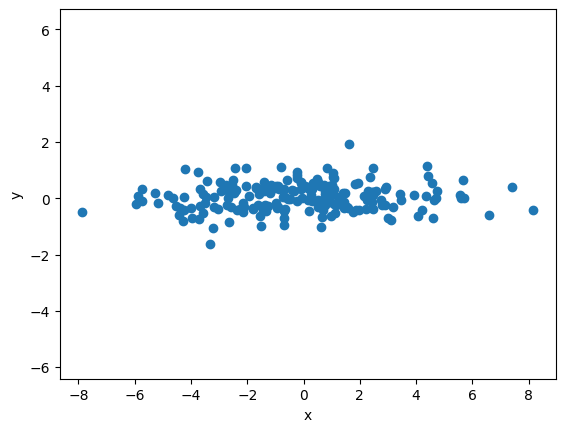

In [45]:
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

In [46]:
pca = PCA(n_components=1)

X_pca = pca.fit_transform(X)

print(X.shape)
print(X_pca.shape)

(200, 2)
(200, 1)


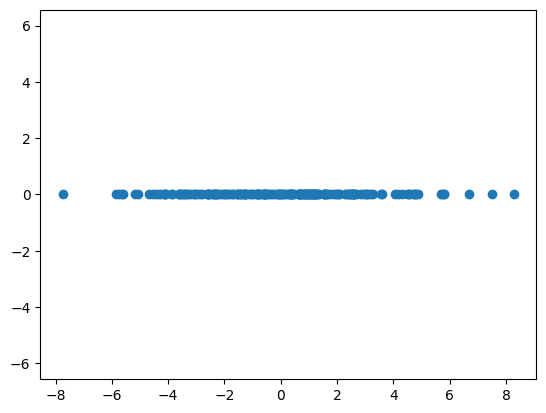

In [47]:
plt.scatter(X_pca[:, 0], np.zeros(len(X_pca)))
plt.axis('equal')
plt.show()

In [48]:
print(pca.components_)

[[0.99984955 0.01734557]]


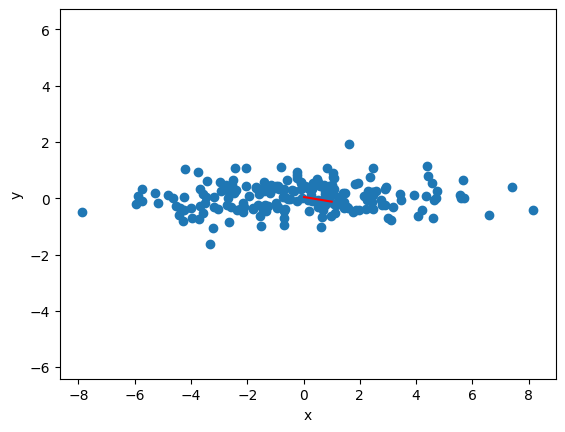

In [49]:
plt.scatter(x, y)
component = pca.components_[0]
mean = pca.mean_
plt.plot(component, mean, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

In [50]:
print(pca.explained_variance_)
print(pca.explained_variance_ratio_[0])

[7.80318976]
0.970008052280869


In [51]:
X_restored = pca.inverse_transform(X_pca)
print(X_restored.shape)

(200, 2)


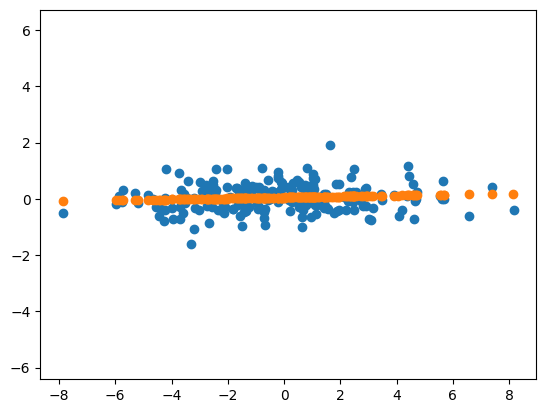

In [52]:
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(X_restored[:, 0], X_restored[:, 1])
plt.axis('equal')
plt.show()

In [53]:
mse = np.mean((X-X_restored) ** 2)
print(mse)

0.12003132054314264


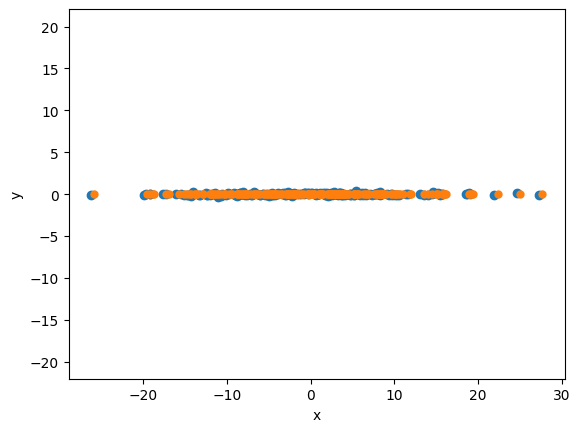

In [54]:
np.random.seed(42)
n = 200
x = np.random.normal(0, 10, n)
y = np.random.normal(0, 0.1, n)

X = np.column_stack([x, y])
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

plt.scatter(x, y)
plt.scatter(X_pca[:, 0], np.zeros(len(X_pca)), linewidth=0.01)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

In [55]:
print(pca.explained_variance_ratio_[0])

X_restored = pca.inverse_transform(X_pca)
mse = np.mean((X - X_restored)**2)
print(mse)

0.9998886382955915
0.004802648224924596


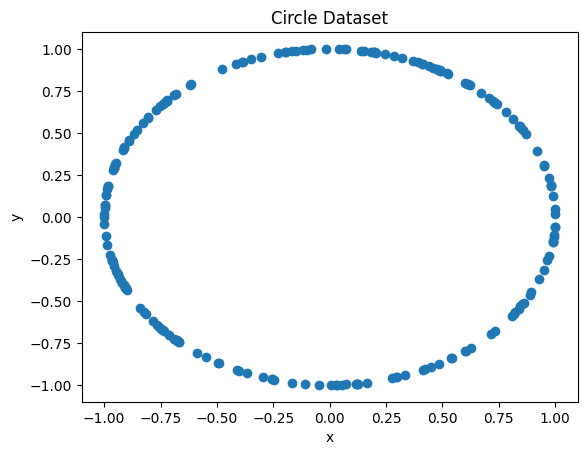

In [63]:
t = np.random.uniform(0, 2*np.pi, 200)
X_circle = np.column_stack([np.sin(t), np.cos(t)])

plt.scatter(X_circle[:, 0], X_circle[:, 1])
plt.title('Circle Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

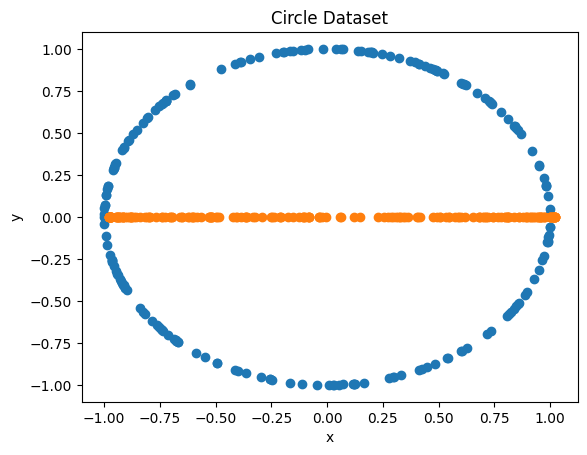

In [64]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_circle)

plt.scatter(X_circle[:, 0], X_circle[:, 1])
plt.scatter(X_pca[:, 0], np.zeros(len(X_pca)))
plt.title('Circle Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [58]:
pca.components_

array([[0.63226796, 0.77474978]])

In [59]:
pca.explained_variance_ratio_

array([0.5385358])

In [73]:
X_scaled_bad = X.copy()
X_scaled_bad[:, 1] *= 100

print(PCA(1).fit(X).components_)
print(PCA(1).fit(X_scaled_bad).components_)

[[0.99999949 0.00100881]]
[[0.48816255 0.87275273]]


In [75]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X_scaled_bad)

print(PCA(1).fit(X).components_)
print(PCA(1).fit(X_std).components_)

[[0.99999949 0.00100881]]
[[0.70710678 0.70710678]]


In [3]:
X, y = make_blobs(
    n_samples = 500,
    n_features = 10,
    centers = 4,
    random_state = 42
)

X.shape

(500, 10)

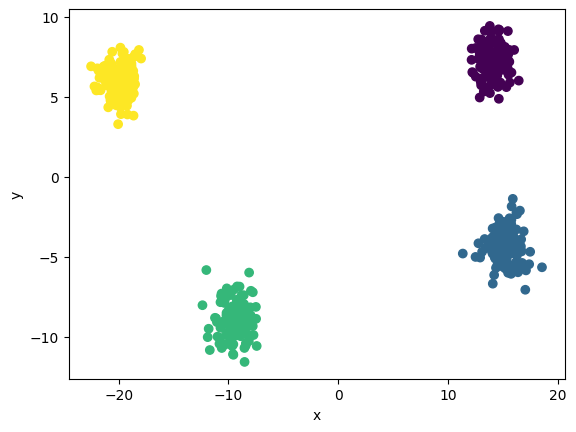

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [5]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.74226629 0.15433026]
0.8965965547547944


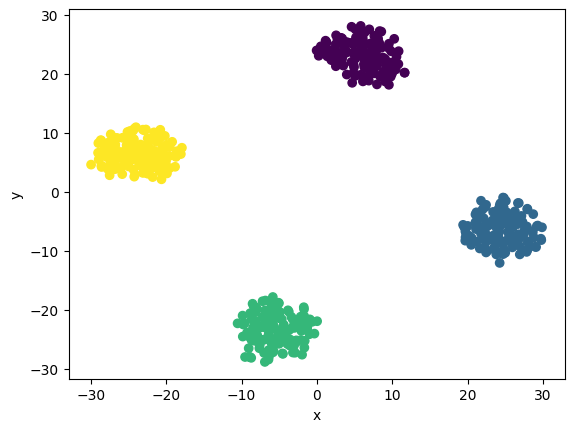

In [6]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1],c=y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

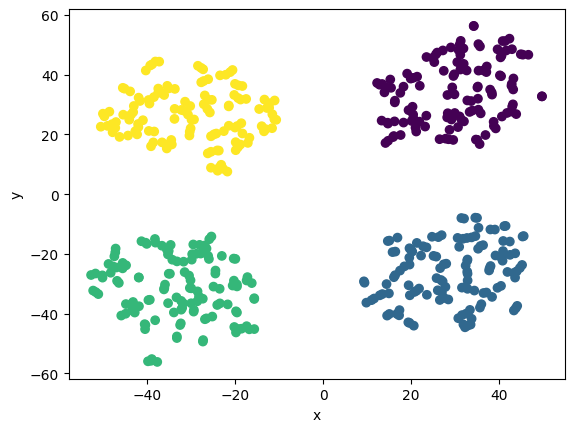

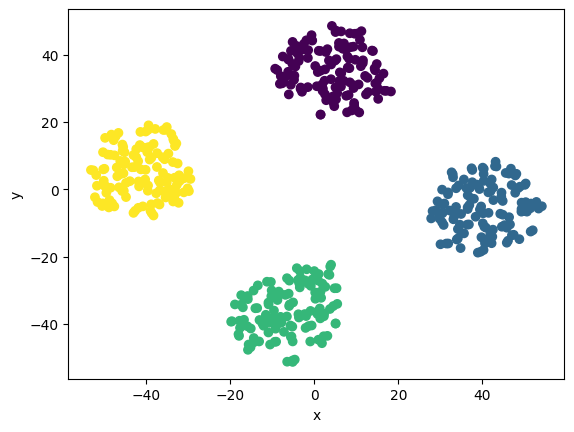

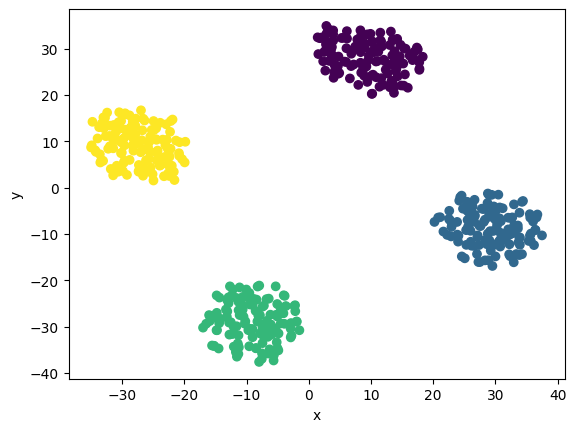

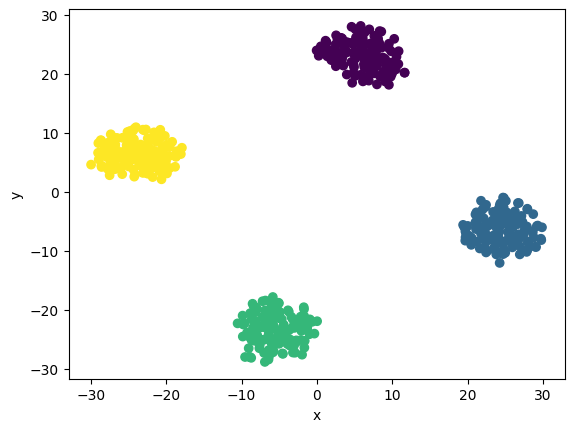

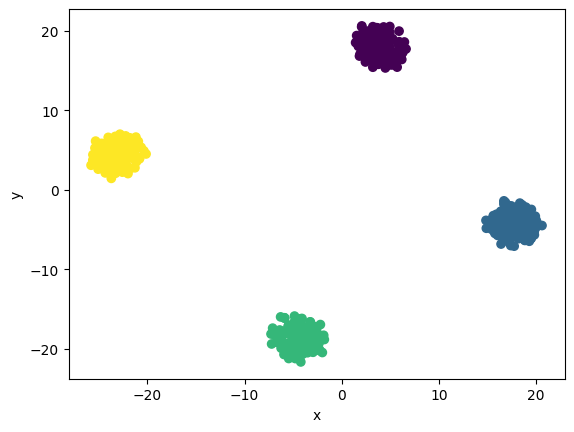

In [7]:
perplexity_values = [5, 10, 20, 30, 50]
for p in perplexity_values:
  tsne = TSNE(n_components=2, perplexity=p, random_state=42)
  X_tsne = tsne.fit_transform(X)
  plt.scatter(X_tsne[:, 0], X_tsne[:, 1],c=y)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()

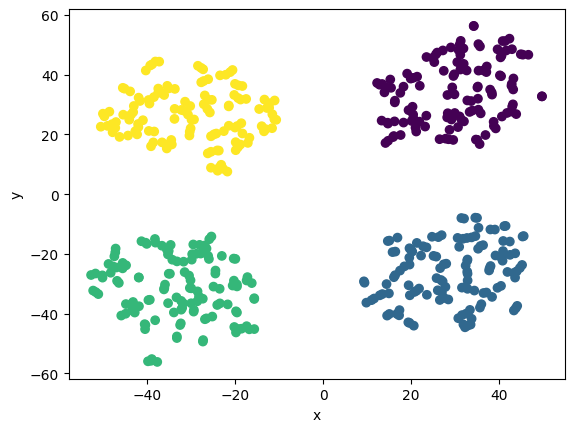

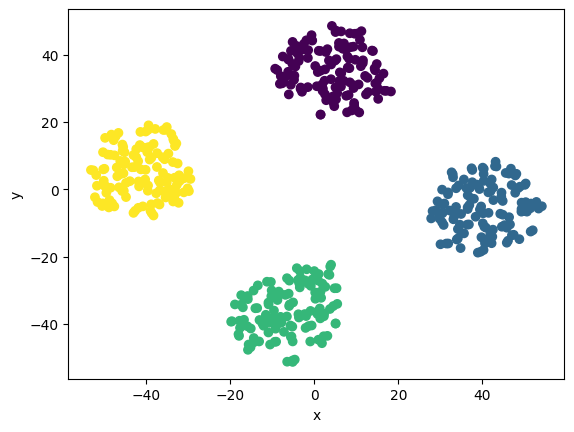

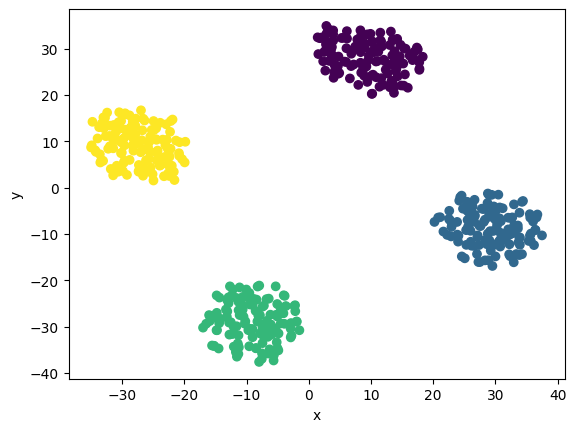

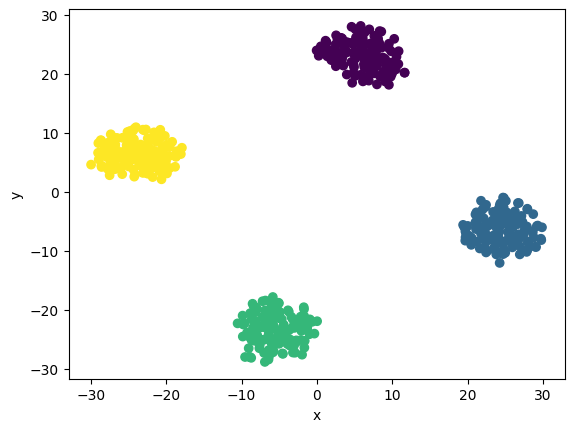

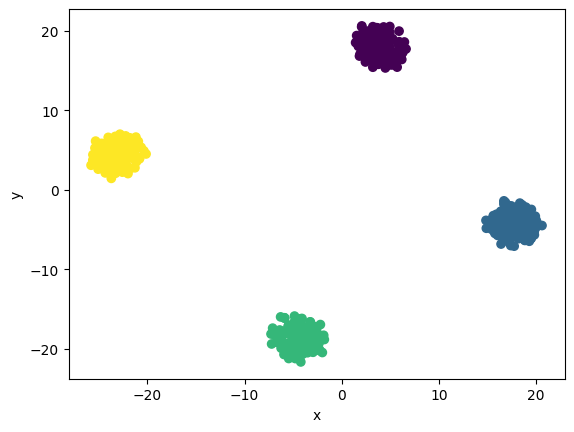

In [8]:
perplexity_values = [5, 10, 20, 30, 50]
for p in perplexity_values:
  tsne = TSNE(n_components=2, perplexity=p, random_state=100)
  X_tsne = tsne.fit_transform(X)
  plt.scatter(X_tsne[:, 0], X_tsne[:, 1],c=y)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()

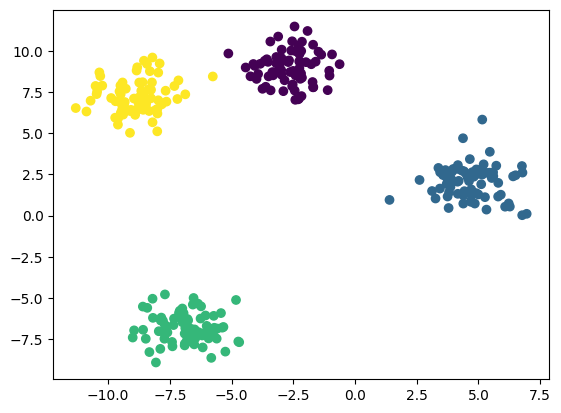

In [9]:
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

[0 1]


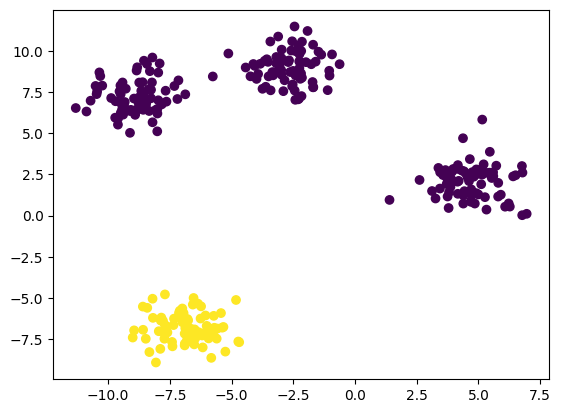

[0 1 2]


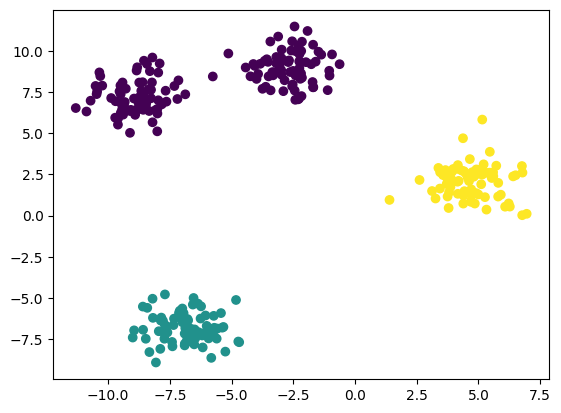

[0 1 2 3]


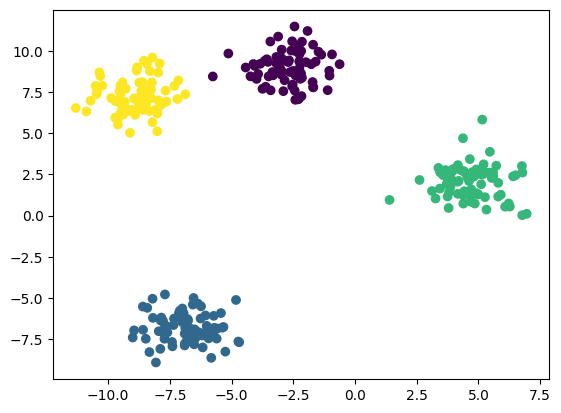

[0 1 2 3 4 5]


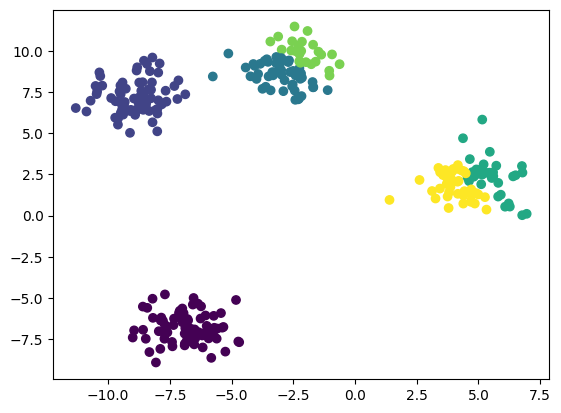

In [10]:
numclust = [2,3,4,6]

for n in numclust:
    agg = AgglomerativeClustering(n)
    labels = agg.fit_predict(X)
    print(np.unique(labels))

    plt.scatter(X[:,0], X[:,1], c=labels)
    plt.show()

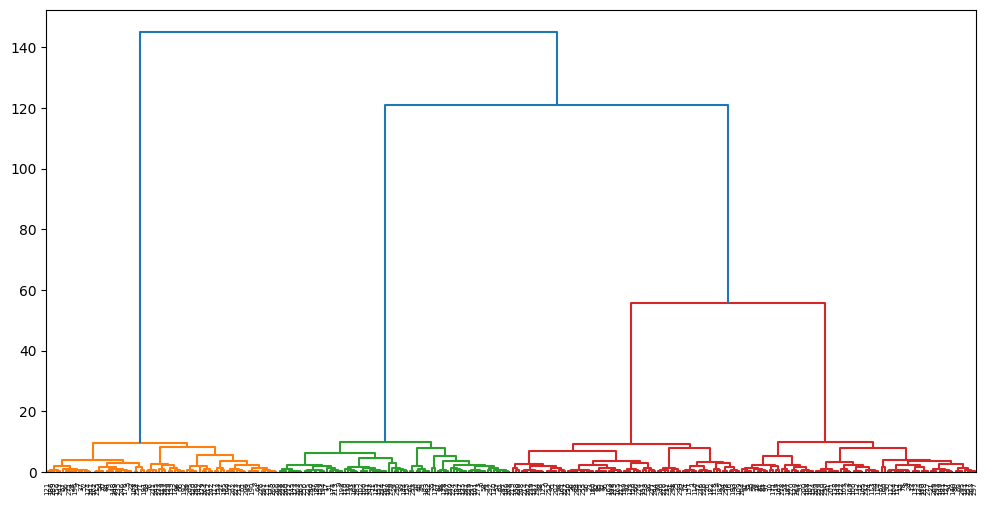

In [11]:
Z = linkage(X, method='ward')
plt.figure(figsize=(12,6))
dendrogram(Z)
plt.show()

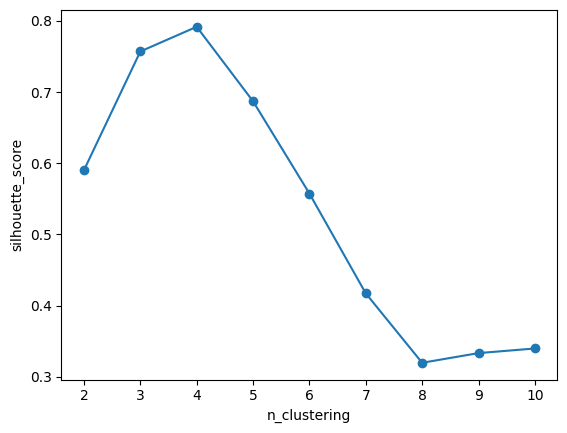

In [12]:
scores = []
for k in range(2, 11):
  agg = AgglomerativeClustering(k)
  labels = agg.fit_predict(X)
  score = silhouette_score(X, labels)
  scores.append(score)

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("n_clustering")
plt.ylabel("silhouette_score")
plt.show()

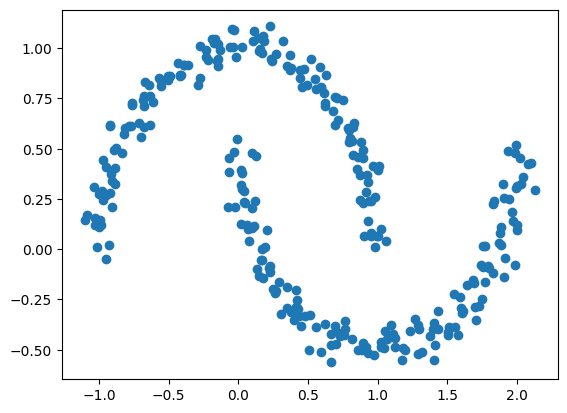

In [14]:
X, _ = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

plt.scatter(X[:,0], X[:,1])
plt.show()

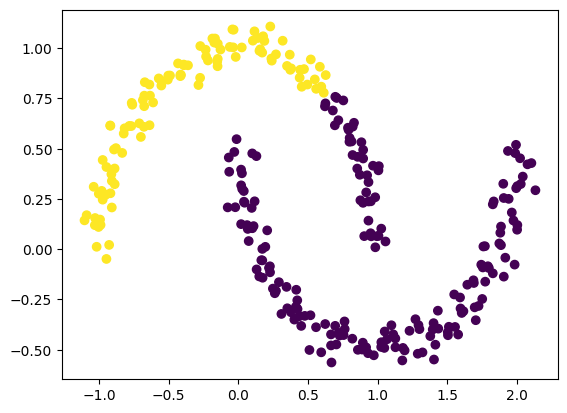

In [16]:
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.show()

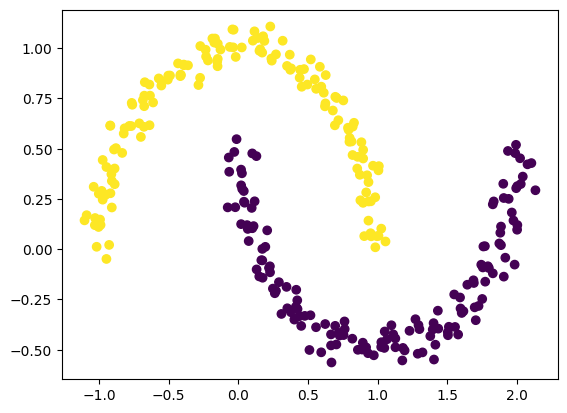

In [20]:
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.show()

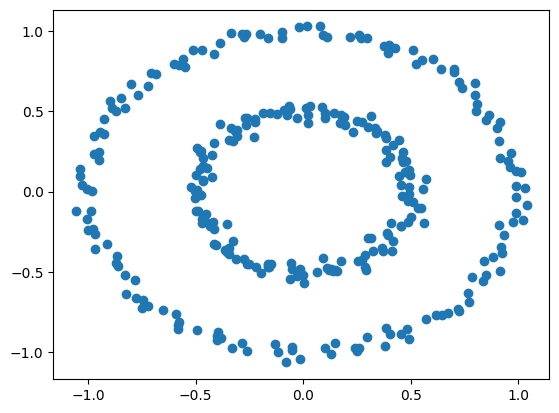

In [2]:
X, _ = make_circles(
    n_samples=300,
    factor=0.5,
    noise=0.03,
    random_state=42
)

plt.scatter(X[:,0], X[:,1])
plt.show()

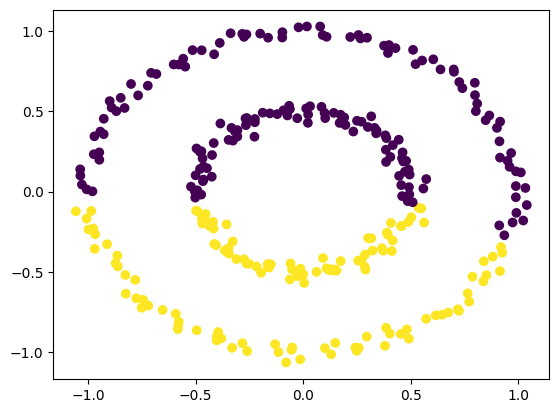

In [29]:
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agg.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

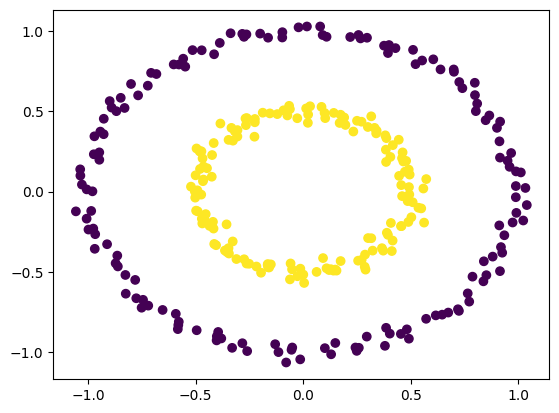

In [88]:
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

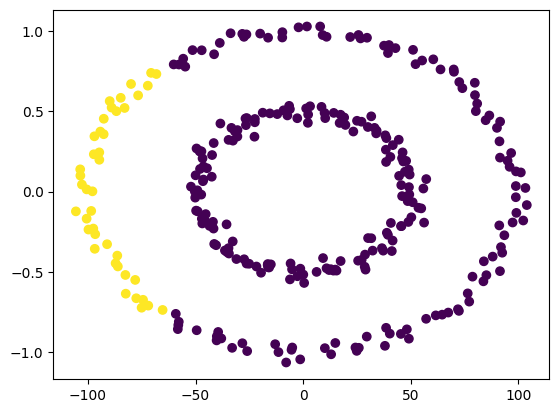

In [90]:
X_bad = X.copy()
X_bad[:,0] *= 100

agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X_bad)

plt.scatter(X_bad[:,0], X_bad[:,1], c=labels)
plt.show()

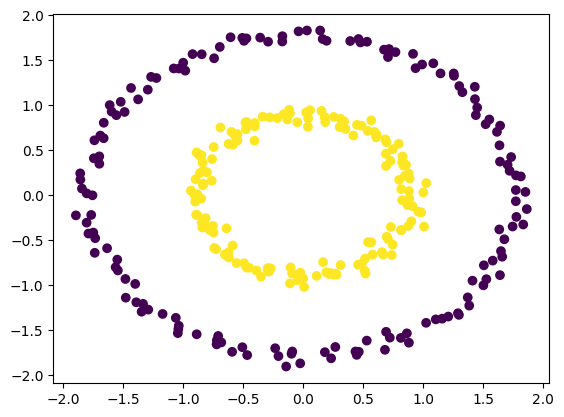

In [92]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X_bad)

agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X_std)

plt.scatter(X_std[:,0], X_std[:,1], c=labels)
plt.show()

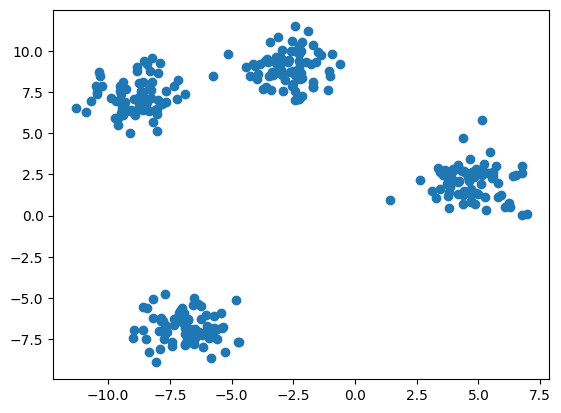

In [3]:
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

plt.scatter(X[:,0], X[:,1])
plt.show()

[-1  0  1  2  3  4]


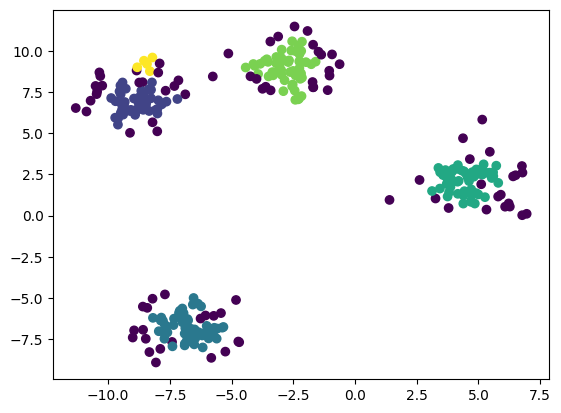

In [32]:
dbscan = DBSCAN()
labels = dbscan.fit_predict(X)
print(np.unique(labels))

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()


In [35]:
unique_labels, counts = np.unique(labels, return_counts=True)
print(unique_labels, counts)

[-1  0  1  2  3  4] [85 48 54 54 54  5]


In [37]:
n_clusters = len(unique_labels[unique_labels != -1])
n_clusters

5

In [48]:
n_noise = (labels == -1).sum()
print(n_noise)

85


eps: 0.1, n_clusters: 0


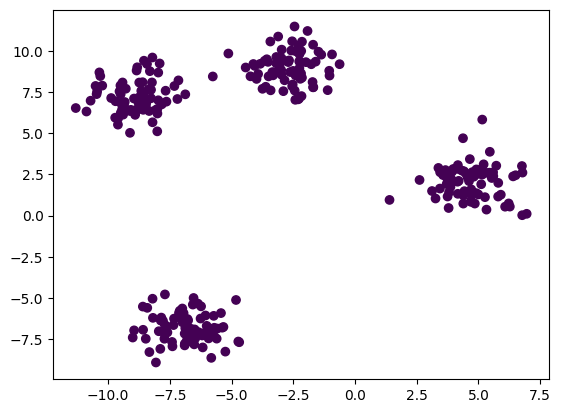

eps: 0.5, n_clusters: 5


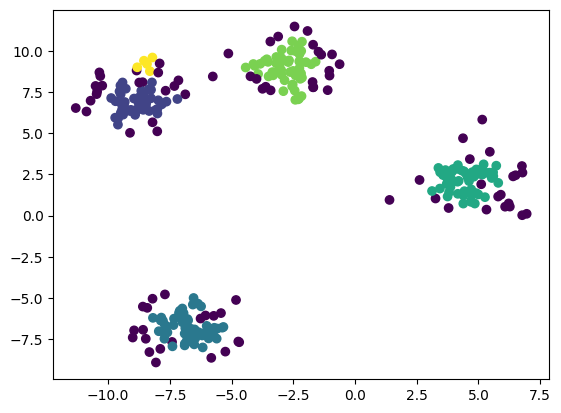

eps: 1, n_clusters: 4


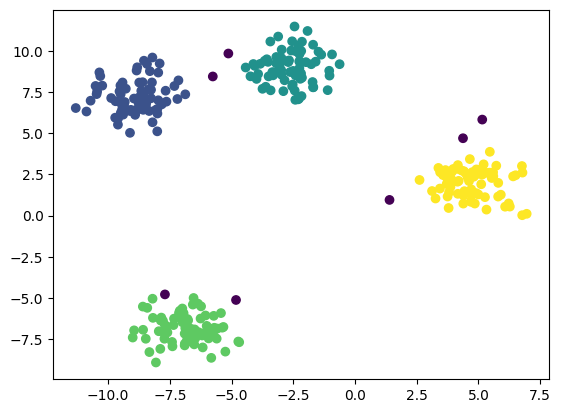

eps: 2, n_clusters: 3


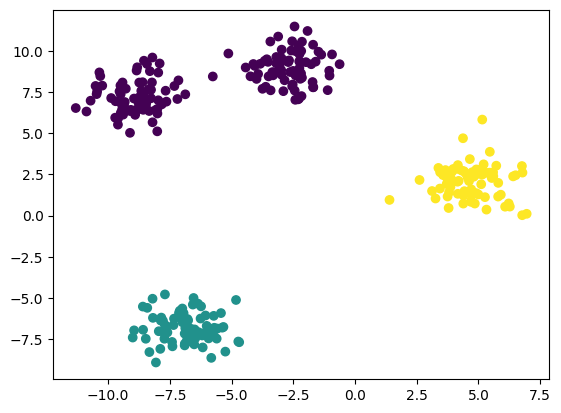

In [51]:
epls = [0.1, 0.5, 1, 2]
for e in epls:
  dbscan = DBSCAN(eps=e, min_samples=5)
  labels = dbscan.fit_predict(X)
  unique_labels, counts = np.unique(labels, return_counts=True)
  n_clusters = len(unique_labels[unique_labels != -1])
  print(f"eps: {e}, n_clusters: {n_clusters}")
  plt.scatter(X[:,0], X[:,1], c=labels)
  plt.show()

eps: 2, n_clusters: 5


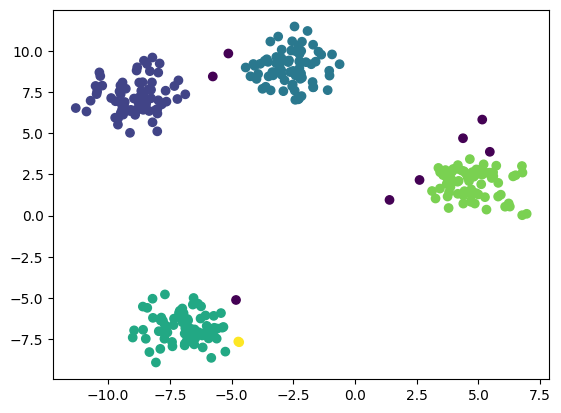

eps: 2, n_clusters: 4


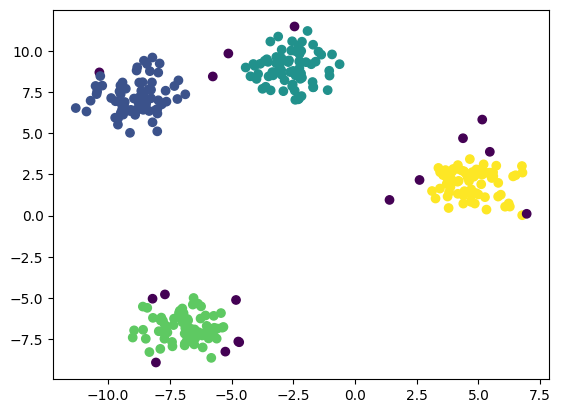

eps: 2, n_clusters: 4


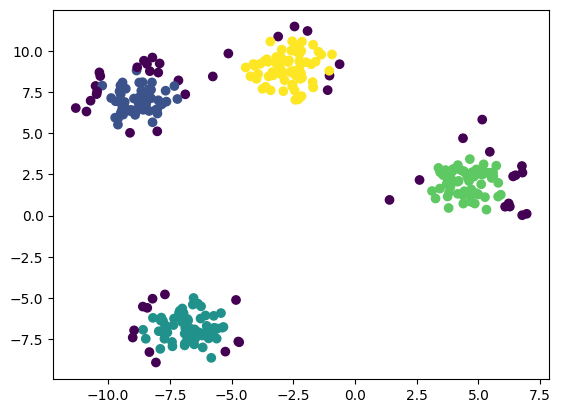

eps: 2, n_clusters: 4


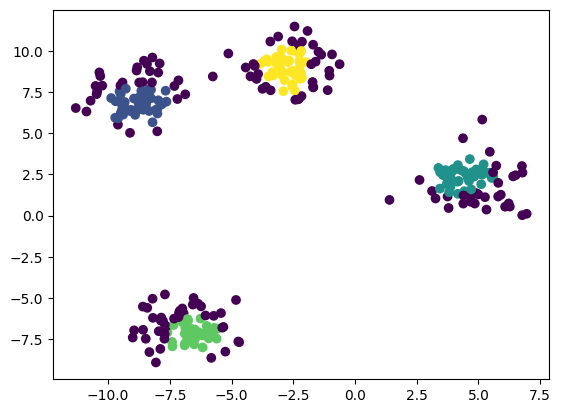

In [54]:
nums = [2, 5, 10, 20]
for n in nums:
  dbscan = DBSCAN(eps=0.8, min_samples=n)
  labels = dbscan.fit_predict(X)
  unique_labels, counts = np.unique(labels, return_counts=True)
  n_clusters = len(unique_labels[unique_labels != -1])
  print(f"eps: {e}, n_clusters: {n_clusters}")
  plt.scatter(X[:,0], X[:,1], c=labels)
  plt.show()

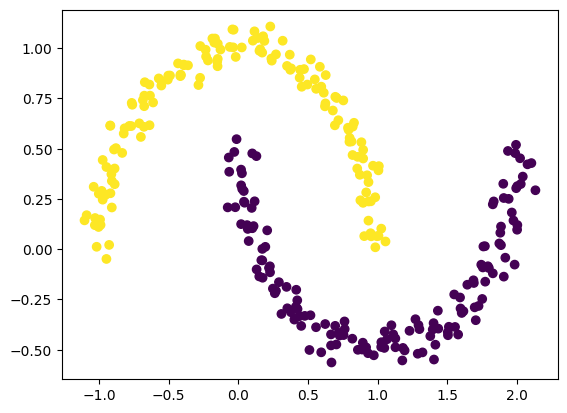

In [62]:
X, _ = make_moons(
    n_samples = 300,
    noise=0.05,
    random_state=42
)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

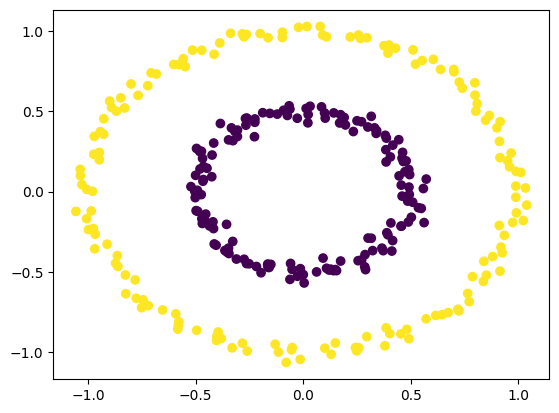

In [65]:
X, _ = make_circles(
    n_samples=300,
    factor=0.5,
    noise=0.03,
    random_state=42
)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

14


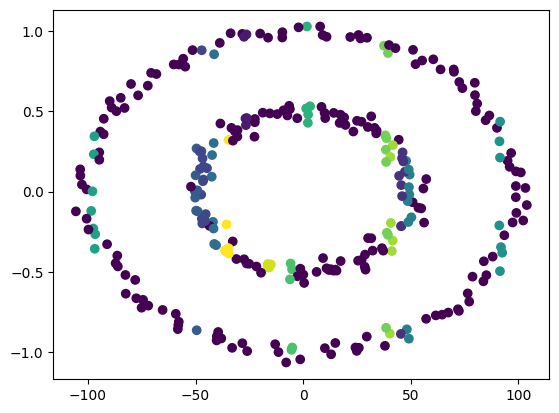

In [74]:
X_bad = X.copy()
X_bad[:,0] *= 100

dbscan = DBSCAN(eps=1, min_samples=5)
labels = dbscan.fit_predict(X_bad)
n_clusters = len(np.unique(labels[labels != -1]))
print(n_clusters)
plt.scatter(X_bad[:,0], X_bad[:,1], c=labels)
plt.show()

2


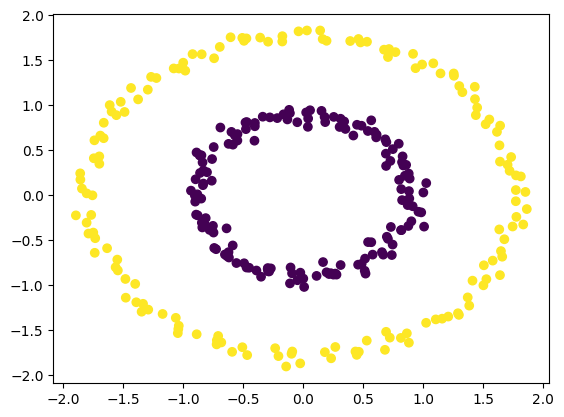

In [93]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X_bad)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_std)
n_clusters = len(np.unique(labels[labels != -1]))
print(n_clusters)
plt.scatter(X_std[:,0], X_std[:,1], c=labels)
plt.show()

In [13]:
def dbscan_clustering(eps_range, X):
  silhouette = []
  clusters = []
  eps_range = eps_range
  for i in tqdm(eps_range):
    dbscan = DBSCAN(eps=i).fit(X)
    labels = dbscan.labels_
    u_labels = np.unique(labels)
    n_clusters = len(u_labels[u_labels != -1])
    if n_clusters > 1:
      score = silhouette_score(X, labels)
    else:
      score = 0
    silhouette.append(score)
    clusters.append(n_clusters)
  fig, ax1 = plt.subplots()
  color = 'tab:red'
  ax1.plot(eps_range, silhouette, marker='o', color=color)
  ax1.set_xlabel('eps')
  ax1.set_ylabel('silhouette', color=color)
  ax1.tick_params(axis='y', labelcolor=color)

  ax2 = ax1.twinx()
  color = 'tab:blue'
  ax2.plot(eps_range, clusters, marker='o', color=color)
  ax2.set_ylabel('n_clusters', color=color)
  ax2.tick_params(axis='y', labelcolor=color)
  fig.tight_layout()
  plt.show()

100%|██████████| 6/6 [00:00<00:00, 115.37it/s]


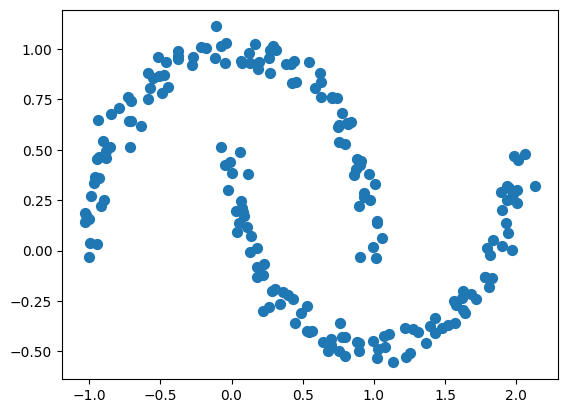

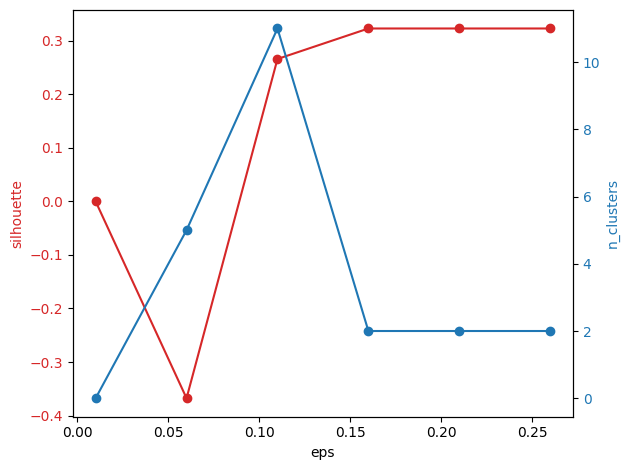

In [16]:
X, _ = make_moons(
    n_samples=200,
    noise=0.05,
    random_state=10
)
plt.scatter(X[:,0], X[:,1], s=50)
eps_range = np.arange(0.01, 0.3, 0.05)
dbscan_clustering(eps_range, X)

2


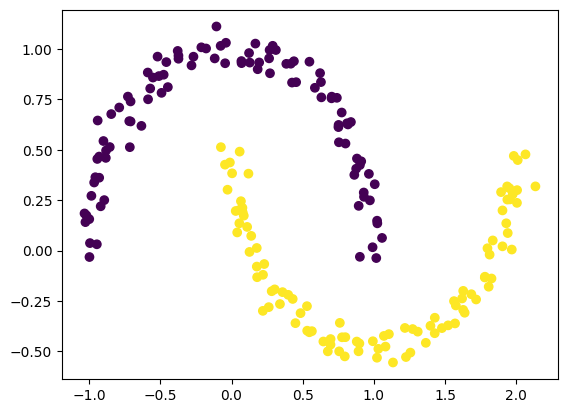

In [17]:
dbscan = DBSCAN(eps=0.2).fit(X)
labels = dbscan.labels_
u_labels = np.unique(labels)
n_clusters = len(u_labels[u_labels != -1])
print(n_clusters)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

100%|██████████| 6/6 [00:00<00:00, 233.49it/s]


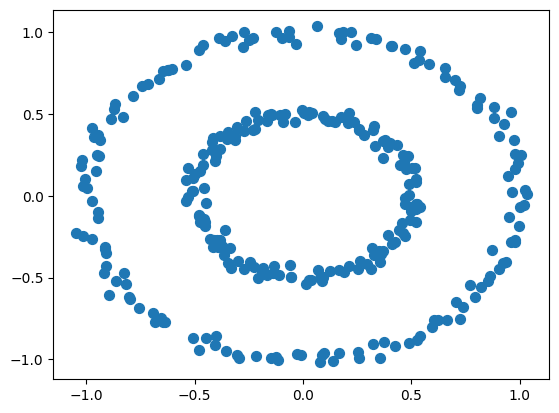

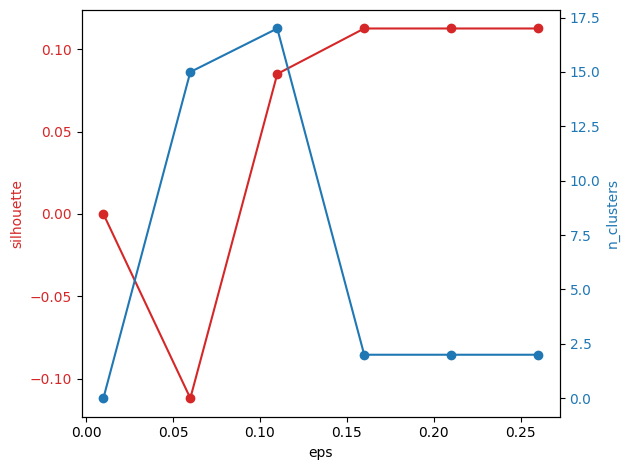

In [18]:
X, _ = make_circles(
    n_samples=300,
    factor=0.5,
    noise=0.03,
    random_state=10
)
plt.scatter(X[:,0], X[:,1], s=50)
eps_range = np.arange(0.01, 0.3, 0.05)
dbscan_clustering(eps_range, X)

2


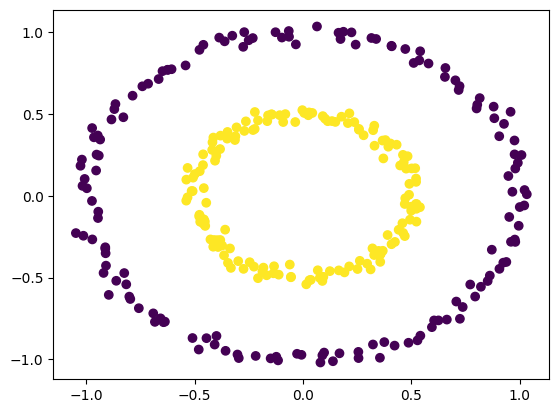

In [19]:
dbscan = DBSCAN(eps=0.2).fit(X)
labels = dbscan.labels_
u_labels = np.unique(labels)
n_clusters = len(u_labels[u_labels != -1])
print(n_clusters)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

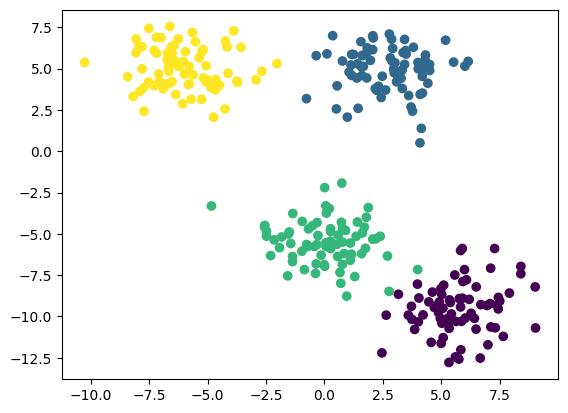

100%|██████████| 19/19 [00:00<00:00, 238.48it/s]


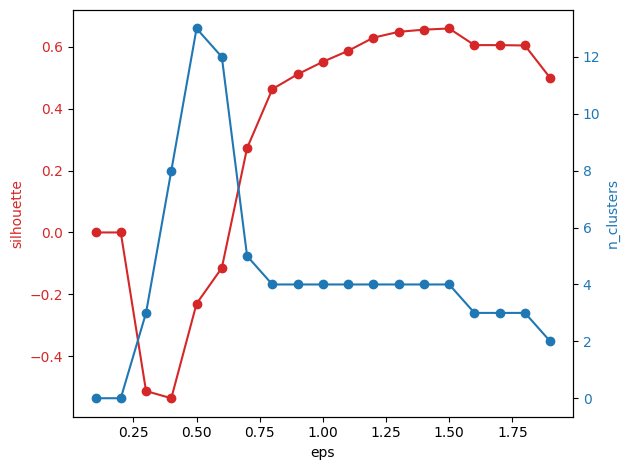

In [23]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.5, random_state=10)
plt.scatter(X[:,0], X[:,1], c=y_true)
plt.show()

eps_range = np.arange(0.1, 2, 0.1)
dbscan_clustering(eps_range, X)

4


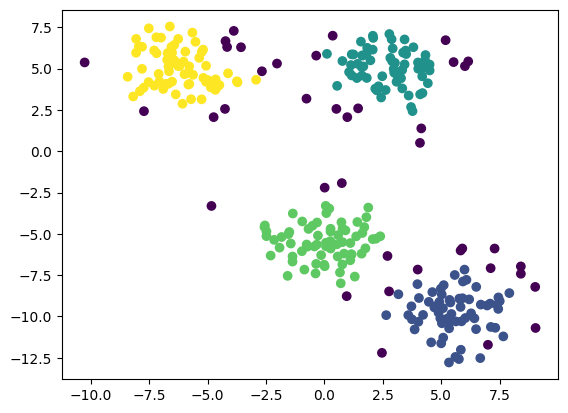

In [24]:
dbscan = DBSCAN(eps=1).fit(X)
labels = dbscan.labels_
u_labels = np.unique(labels)
n_clusters = len(u_labels[u_labels != -1])
print(n_clusters)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

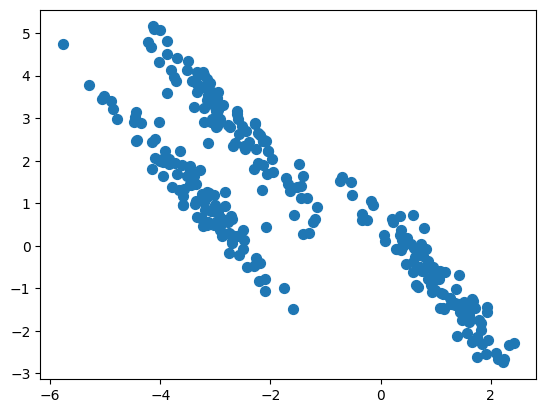

100%|██████████| 19/19 [00:00<00:00, 180.04it/s]


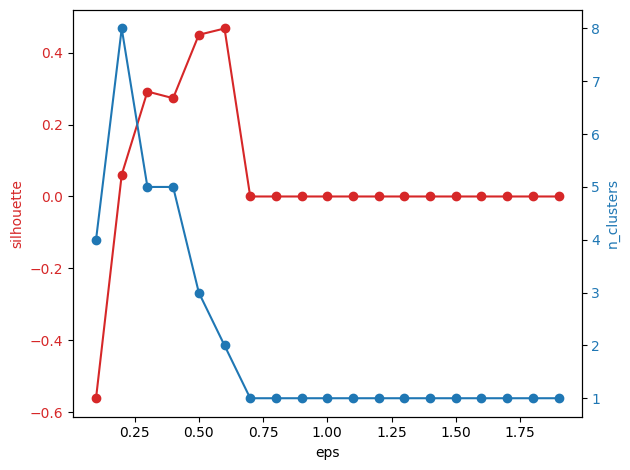

In [26]:
X, y_true = make_blobs(n_samples=300, centers=3, random_state=170)
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X = np.dot(X, transformation)

plt.scatter(X[:,0], X[:,1], s=50)
plt.show()

eps_range = np.arange(0.1, 2, 0.1)
dbscan_clustering(eps_range, X)

3


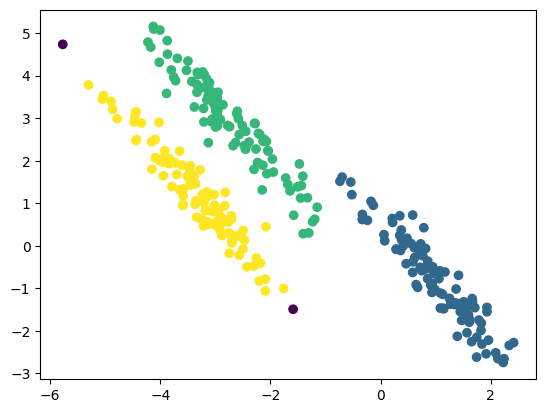

In [31]:
dbscan = DBSCAN(eps=0.5).fit(X)
labels = dbscan.labels_
u_labels = np.unique(labels)
n_clusters = len(u_labels[u_labels != -1])
print(n_clusters)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [32]:
!wget -O data.csv https://drive.usercontent.google.com/download?id=1b6bK8V-2fKfKQ8z8zqYQbkjRasUaPFiZ&export=download&authuser=0&confirm=t&uuid=09175432-4e29-4265-98b2-03b28c9212c5&at=AO7h07eejM3soJYP_v4aDNZKJhyf:1725021024305

--2026-08-23 14:56:24--  https://drive.usercontent.google.com/download?id=1b6bK8V-2fKfKQ8z8zqYQbkjRasUaPFiZ
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.155.132, 2607:f8b0:4004:c23::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.155.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8822 (8.6K) [application/octet-stream]
Saving to: ‘data.csv’

data.csv            100%[===================>]   8.62K  --.-KB/s    in 0s      

2026-08-23 14:56:25 (62.4 MB/s) - ‘data.csv’ saved [8822/8822]



In [44]:
import pandas as pd

data = pd.read_csv('data.csv')
data.shape

(156, 9)

In [45]:
data

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [47]:
data.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [48]:
data['Overall rank'].nunique()
data.drop('Overall rank', axis=1, inplace=True)
data['Country or region'].nunique()

156

In [49]:
country = data['Country or region']
data.drop('Country or region', axis=1, inplace=True)

In [50]:
data.describe()

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


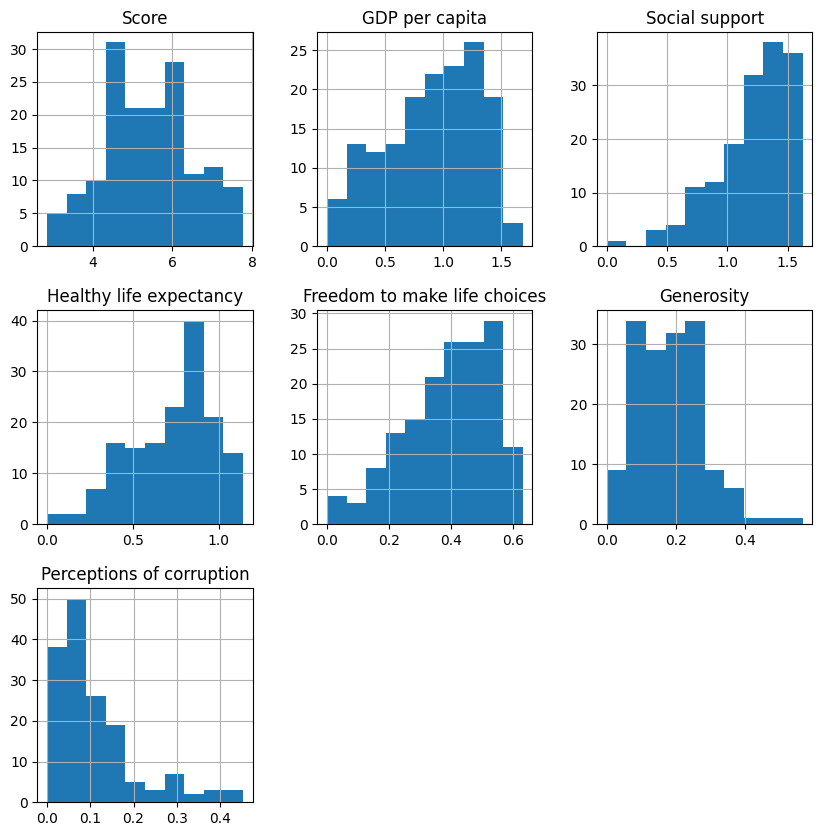

In [53]:
data.hist(figsize=(10, 10))
plt.show()

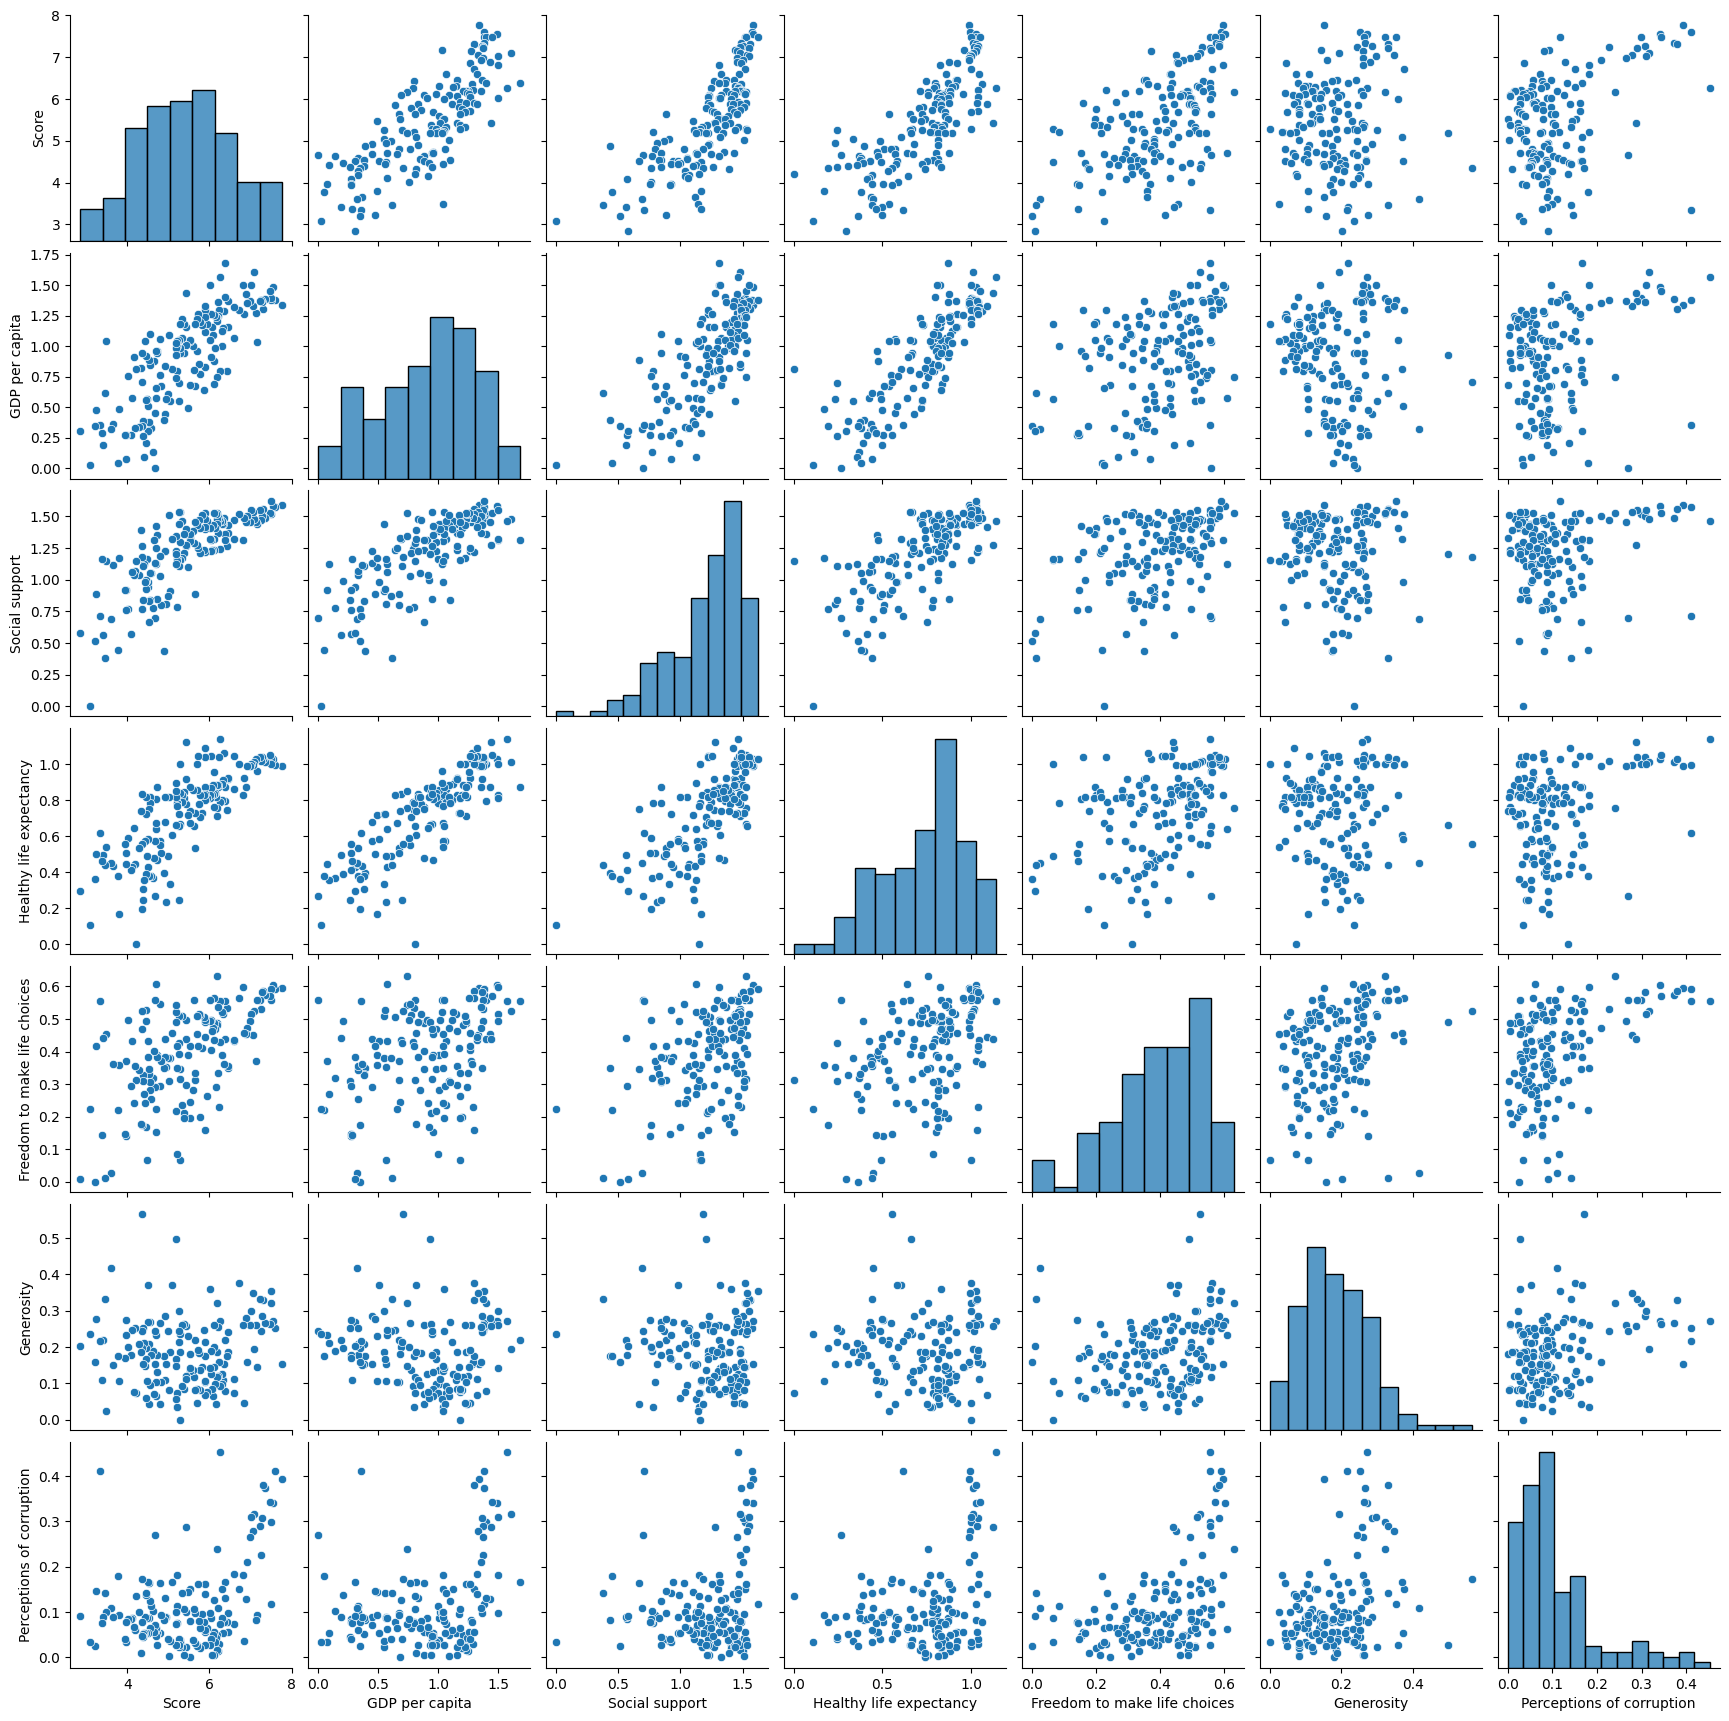

In [55]:
import seaborn as sns

sns.pairplot(data)
plt.show()

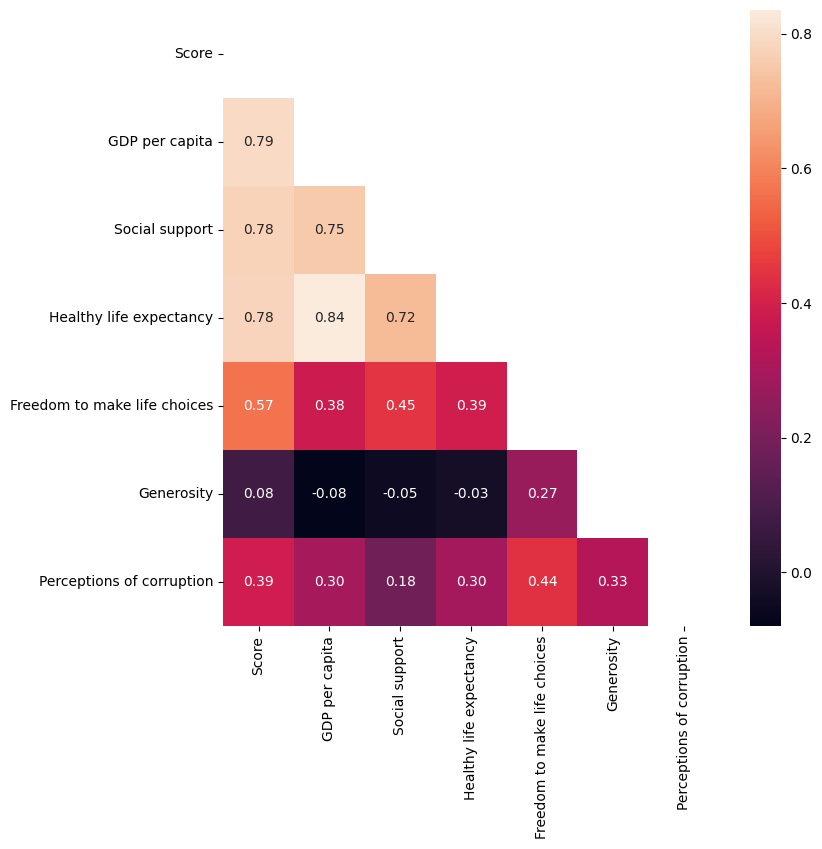

In [58]:
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f')
plt.show()

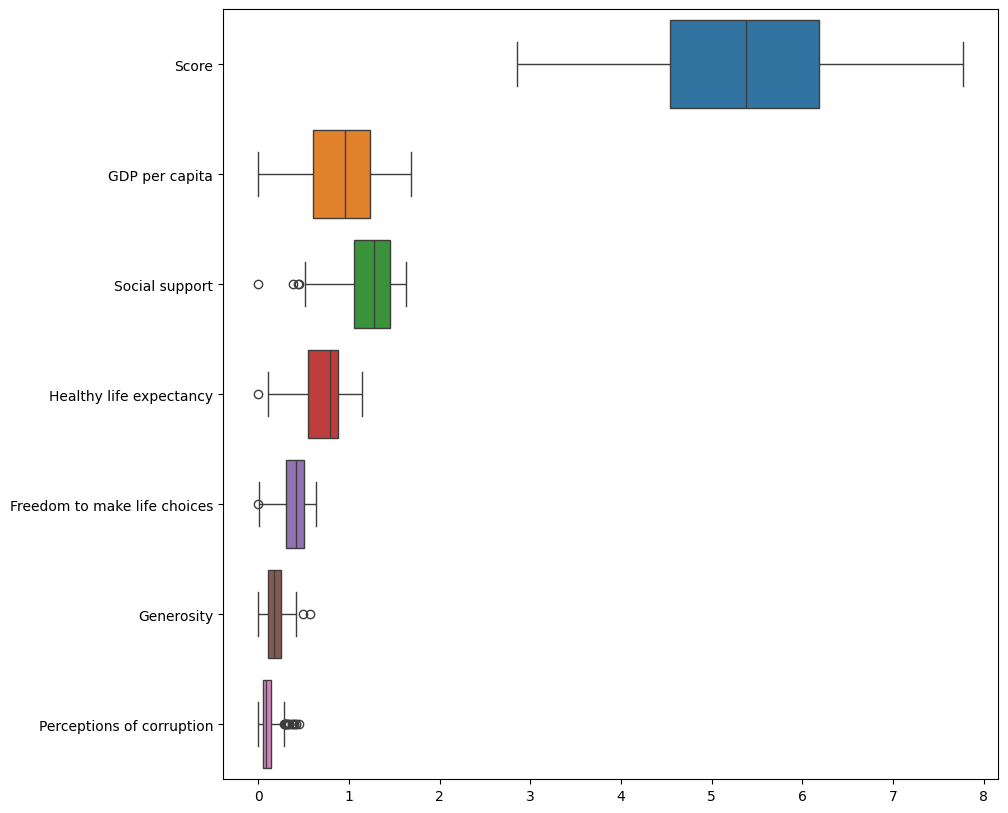

In [59]:
plt.figure(figsize=(10, 10))
sns.boxplot(data=data, orient='h')
plt.show()

In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(X_scaled, columns=data.columns)
data_scaled

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1.000000,0.795724,0.977217,0.864154,0.944532,0.270318,0.867550
1,0.965622,0.821259,0.968596,0.872918,0.938193,0.445230,0.905077
2,0.956265,0.883610,0.974138,0.900964,0.955626,0.478799,0.752759
3,0.944060,0.819477,1.000000,0.899211,0.936609,0.625442,0.260486
4,0.942840,0.828979,0.937192,0.875548,0.882726,0.568905,0.657837
...,...,...,...,...,...,...,...
151,0.097844,0.213183,0.437808,0.538124,0.879556,0.383392,0.907285
152,0.076892,0.282660,0.544951,0.437336,0.660856,0.487633,0.324503
153,0.071196,0.207838,0.318350,0.316389,0.000000,0.279152,0.055188
154,0.046786,0.015439,0.000000,0.092025,0.356577,0.415194,0.077263


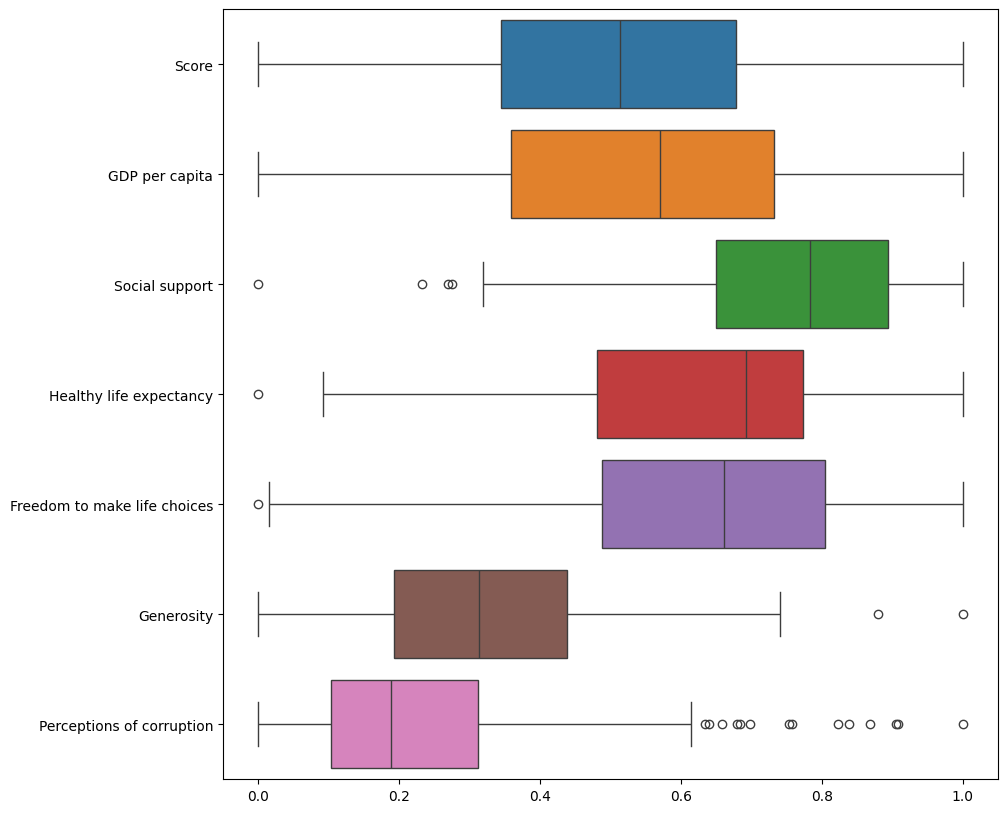

In [61]:
plt.figure(figsize=(10, 10))
sns.boxplot(data=data_scaled, orient='h')
plt.show()

In [62]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=10)
X_scaled.shape

(156, 7)

In [63]:
X_tsne = tsne.fit_transform(X_scaled)
X_tsne.shape

(156, 2)

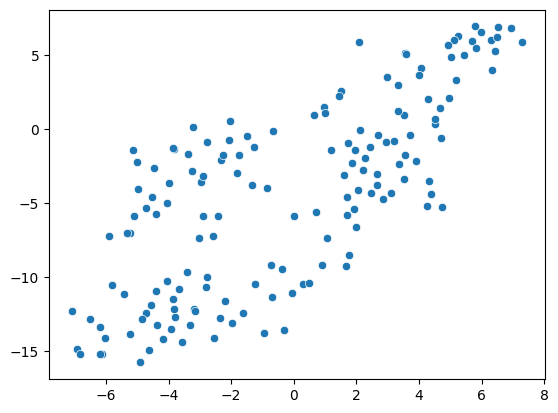

In [67]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1])
plt.show()

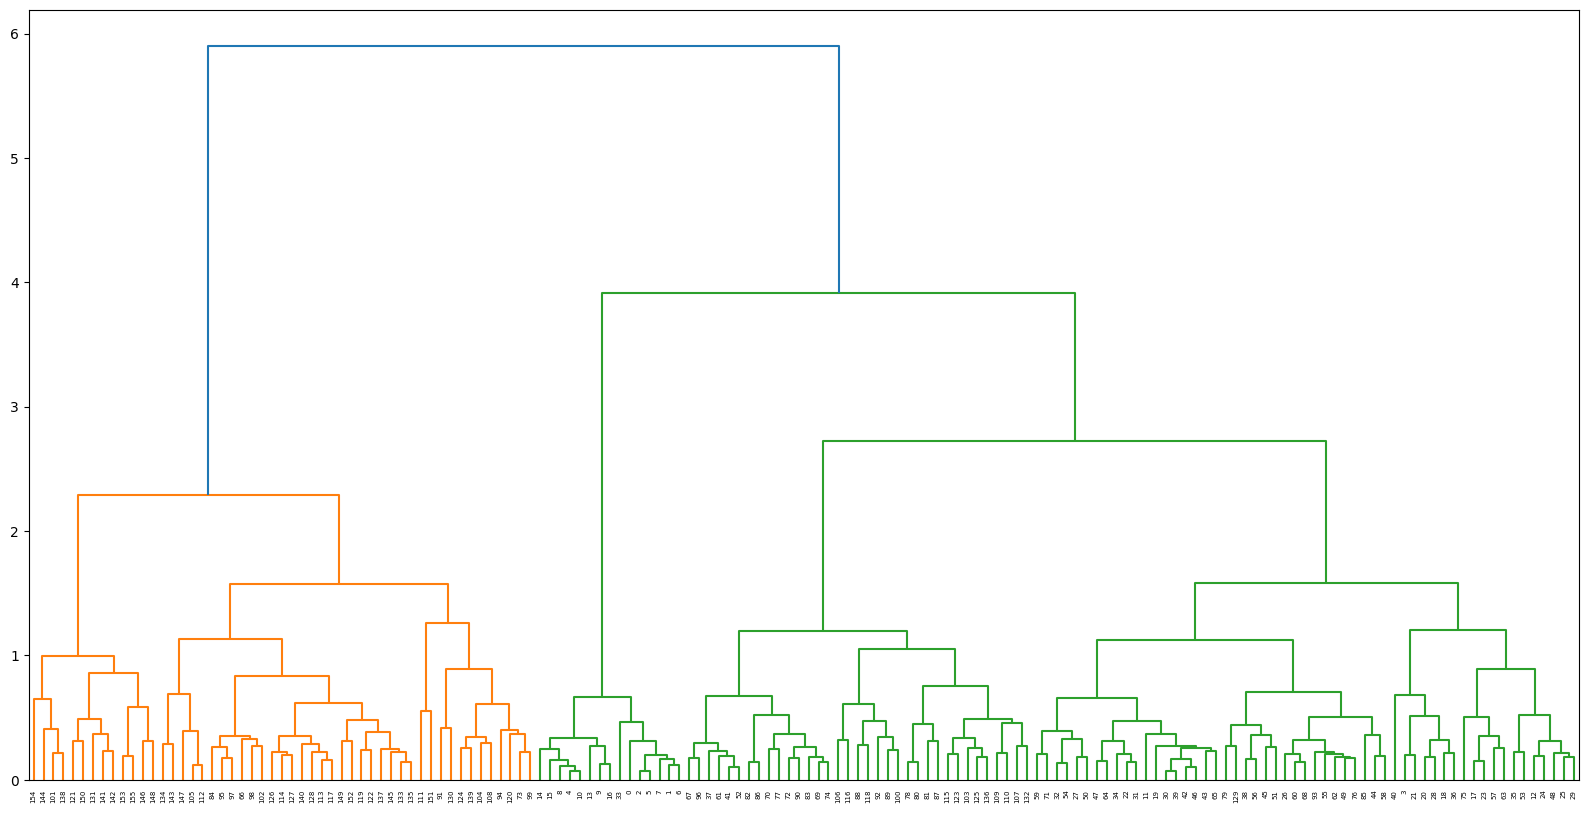

In [69]:
plt.figure(figsize=(20, 10))
linkage_ = linkage(X_scaled, method='ward')
dendrogram_ = dendrogram(linkage_)

100%|██████████| 9/9 [00:00<00:00, 223.97it/s]


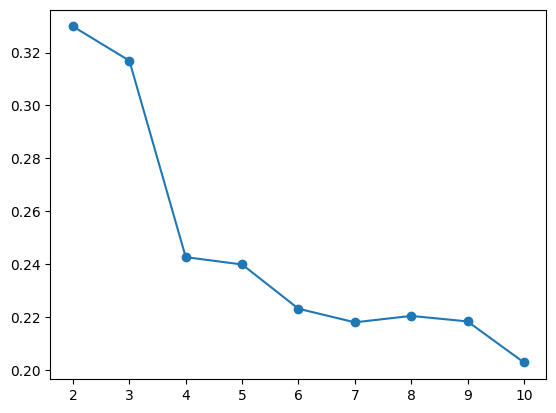

In [72]:
silhouette = []
for i in tqdm(range(2, 11)):
  agg = AgglomerativeClustering(n_clusters=i).fit(X_scaled)
  labels = agg.labels_
  score = silhouette_score(X_scaled, labels)
  silhouette.append(score)

plt.plot(range(2,11), silhouette, marker='o')
plt.show()

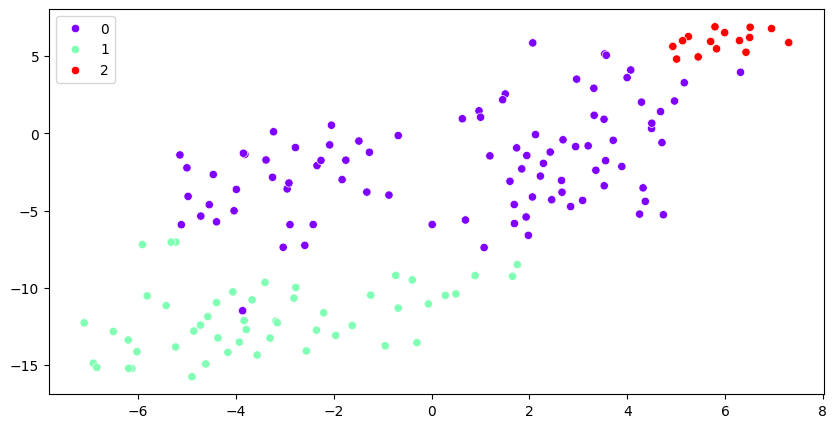

In [95]:
agg = AgglomerativeClustering(n_clusters=3).fit(X_scaled)
labels = agg.labels_
plt.figure(figsize=(10,5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='rainbow')
plt.show()

In [96]:
data['labels'] = labels
data['labels'].value_counts(normalize=True)

,proportion
labels,
0,0.576923
1,0.326923
2,0.096154


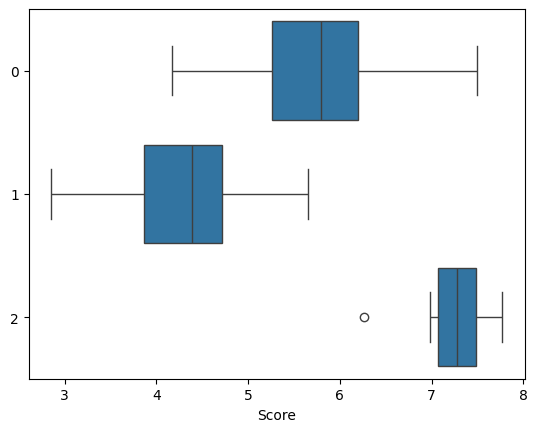

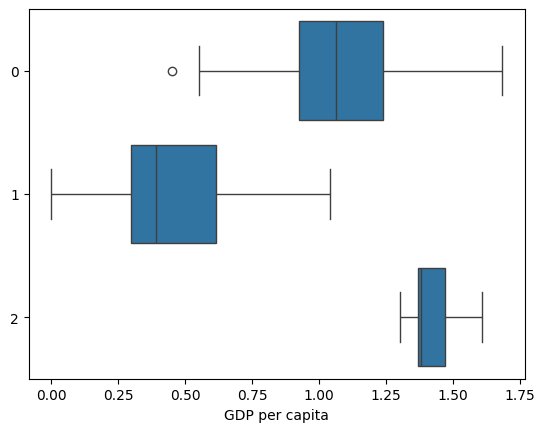

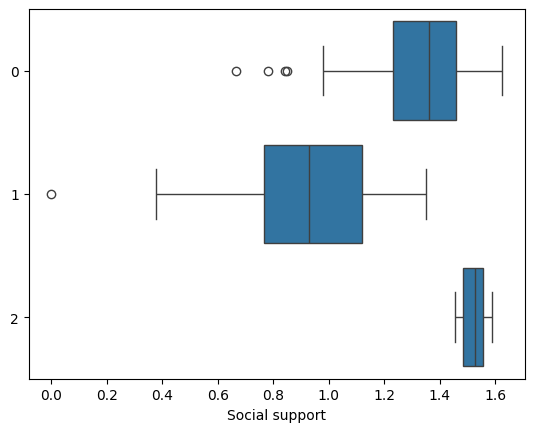

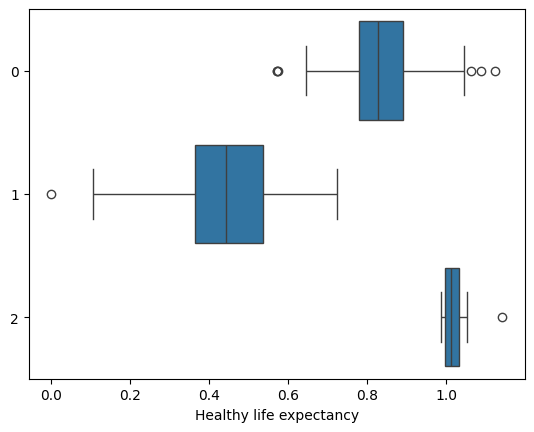

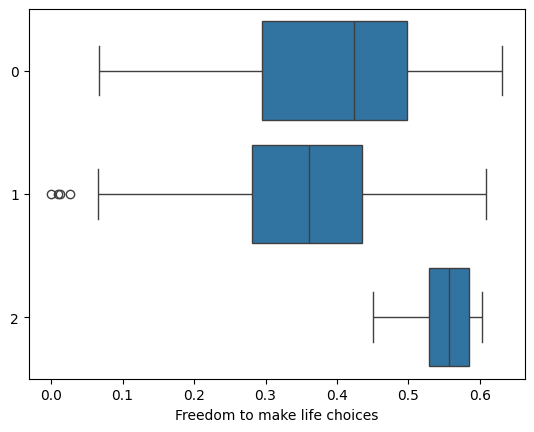

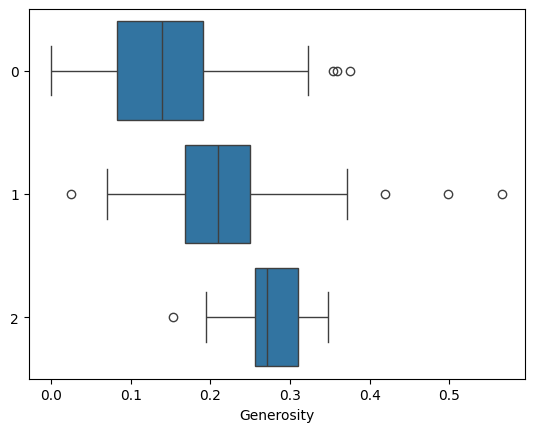

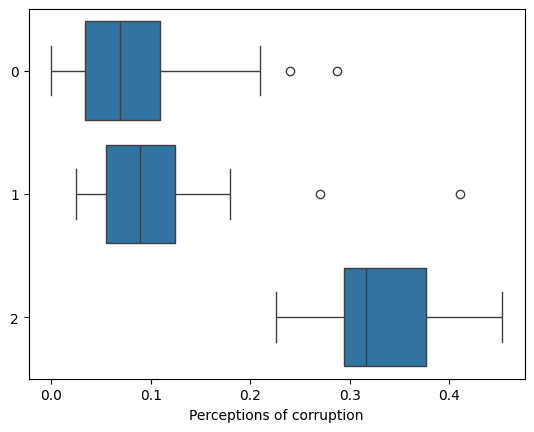

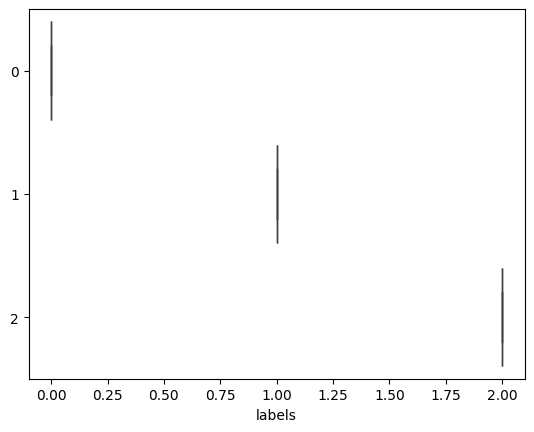

In [77]:
for c in data.columns:
  sns.boxplot(data=data, x=c, y=labels, orient='h')
  plt.show()

In [97]:
data.groupby('labels').median().T.round(2)

labels,0,1,2
Score,5.79,4.39,7.28
GDP per capita,1.06,0.39,1.38
Social support,1.36,0.93,1.53
Healthy life expectancy,0.83,0.44,1.01
Freedom to make life choices,0.42,0.36,0.56
Generosity,0.14,0.21,0.27
Perceptions of corruption,0.07,0.09,0.32


In [100]:
country[data['labels'] == 1]

,Country or region
66,Pakistan
73,Tajikistan
84,Nigeria
91,Indonesia
94,Bhutan
95,Cameroon
97,Ghana
98,Ivory Coast
99,Nepal
101,Benin


100%|██████████| 19/19 [00:00<00:00, 273.33it/s]


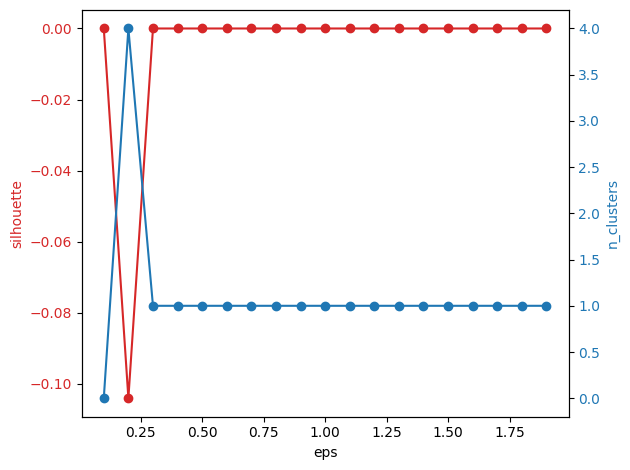

In [80]:
eps_range = np.arange(0.1, 2, 0.1)
dbscan_clustering(eps_range, X_scaled)

100%|██████████| 31/31 [00:00<00:00, 210.04it/s]


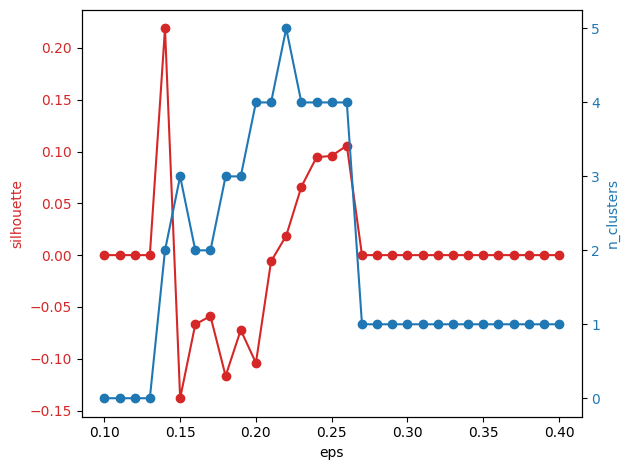

In [81]:
eps_range = np.arange(0.1, 0.4, 0.01)
dbscan_clustering(eps_range, X_scaled)

100%|██████████| 20/20 [00:00<00:00, 120.02it/s]


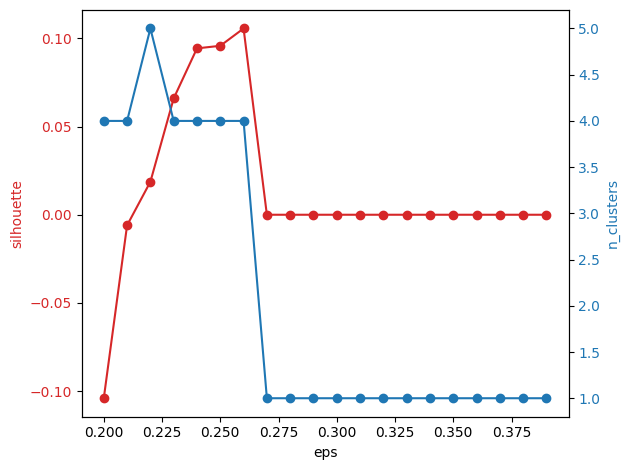

In [82]:
eps_range = np.arange(0.2, 0.4, 0.01)
dbscan_clustering(eps_range, X_scaled)

100%|██████████| 6/6 [00:00<00:00, 144.80it/s]


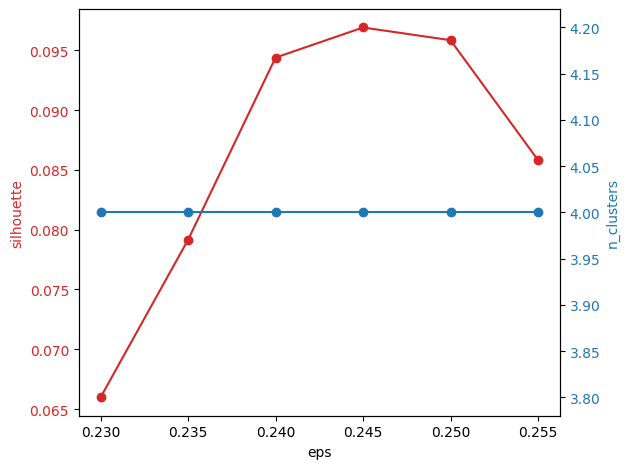

In [83]:
eps_range = np.arange(0.23, 0.26, 0.005)
dbscan_clustering(eps_range, X_scaled)

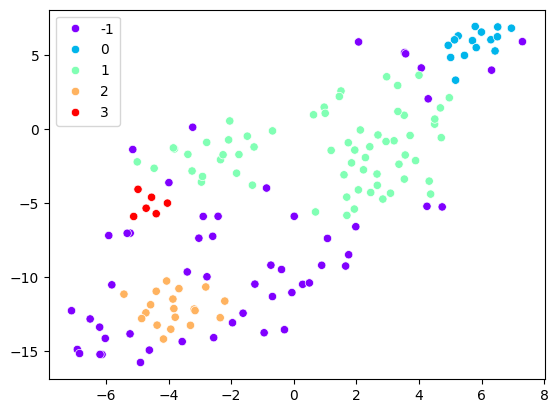

In [86]:
dbscan = DBSCAN(eps=0.245).fit(X_scaled)
labels = dbscan.labels_
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='rainbow')
plt.show()

In [87]:
data['labels'] = labels
data['labels'].value_counts(normalize=True)

,proportion
labels,
1,0.403846
-1,0.339744
2,0.121795
0,0.096154
3,0.038462


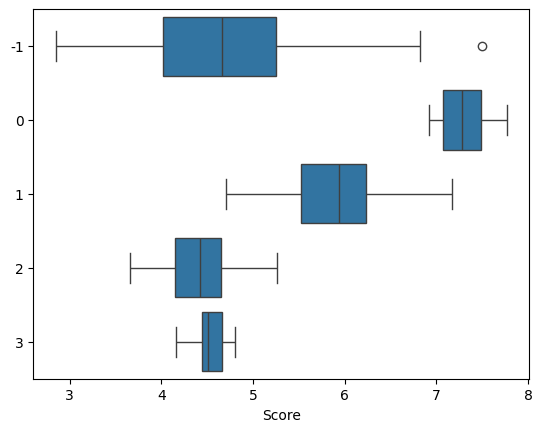

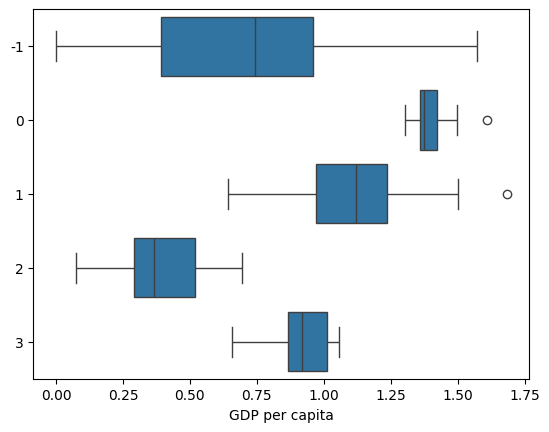

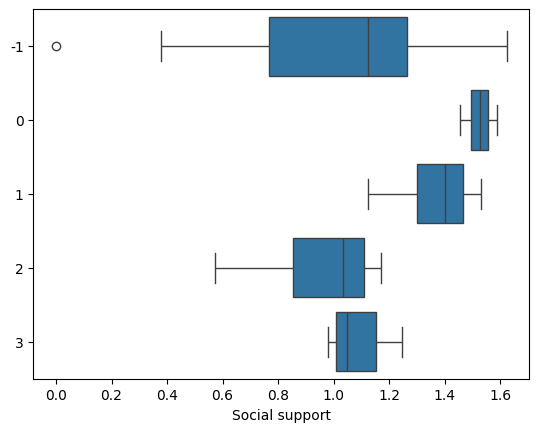

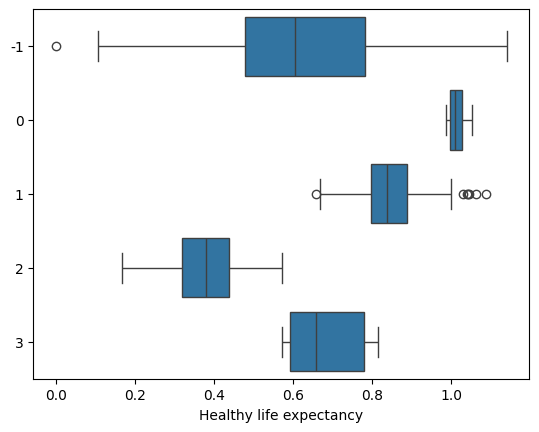

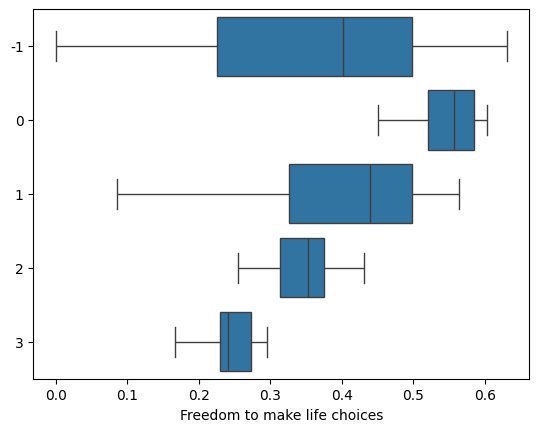

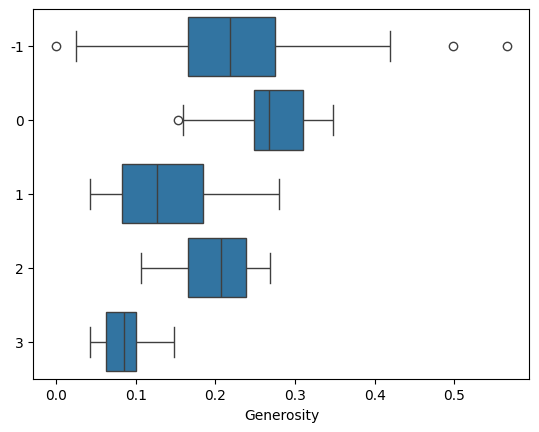

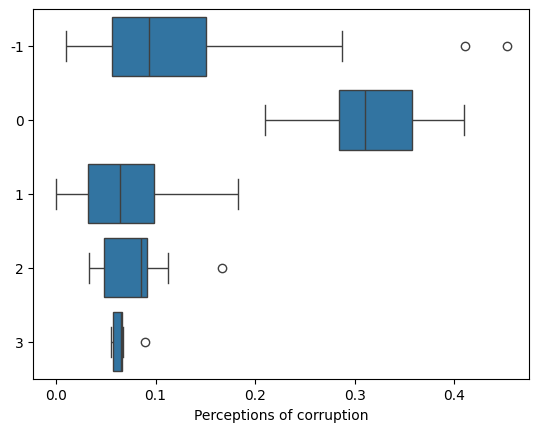

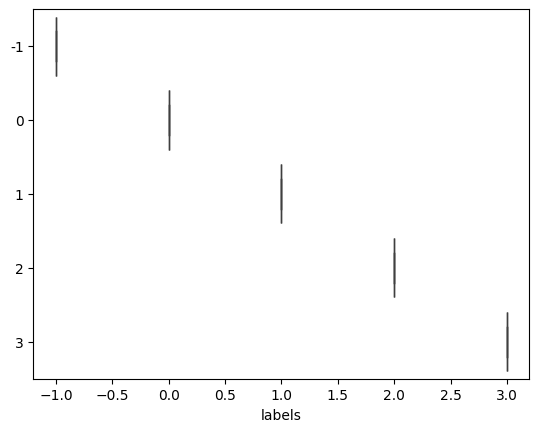

In [88]:
for c in data.columns:
  sns.boxplot(data=data, x=c, y=labels, orient='h')
  plt.show()

In [89]:
data.groupby('labels').median().T.round(2)

labels,-1,0,1,2,3
Score,4.67,7.28,5.94,4.42,4.51
GDP per capita,0.74,1.38,1.12,0.37,0.92
Social support,1.12,1.53,1.40,1.03,1.05
Healthy life expectancy,0.60,1.01,0.84,0.38,0.66
Freedom to make life choices,0.40,0.56,0.44,0.35,0.24
Generosity,0.22,0.27,0.13,0.21,0.09
Perceptions of corruption,0.09,0.31,0.06,0.08,0.06


In [94]:
country[data['labels'] == 3]

,Country or region
103,Gabon
109,Palestinian Territories
115,Armenia
123,Tunisia
125,Iraq
136,Egypt


In [101]:
data.drop('Score', axis=1, inplace=True)

In [102]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(X_scaled, columns=data.columns)
data_scaled

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,labels
0,0.795724,0.977217,0.864154,0.944532,0.270318,0.867550,1.0
1,0.821259,0.968596,0.872918,0.938193,0.445230,0.905077,1.0
2,0.883610,0.974138,0.900964,0.955626,0.478799,0.752759,1.0
3,0.819477,1.000000,0.899211,0.936609,0.625442,0.260486,0.0
4,0.828979,0.937192,0.875548,0.882726,0.568905,0.657837,1.0
...,...,...,...,...,...,...,...
151,0.213183,0.437808,0.538124,0.879556,0.383392,0.907285,0.5
152,0.282660,0.544951,0.437336,0.660856,0.487633,0.324503,0.5
153,0.207838,0.318350,0.316389,0.000000,0.279152,0.055188,0.5
154,0.015439,0.000000,0.092025,0.356577,0.415194,0.077263,0.5


In [107]:
data_scaled

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,0.795724,0.977217,0.864154,0.944532,0.270318,0.867550
1,0.821259,0.968596,0.872918,0.938193,0.445230,0.905077
2,0.883610,0.974138,0.900964,0.955626,0.478799,0.752759
3,0.819477,1.000000,0.899211,0.936609,0.625442,0.260486
4,0.828979,0.937192,0.875548,0.882726,0.568905,0.657837
...,...,...,...,...,...,...
151,0.213183,0.437808,0.538124,0.879556,0.383392,0.907285
152,0.282660,0.544951,0.437336,0.660856,0.487633,0.324503
153,0.207838,0.318350,0.316389,0.000000,0.279152,0.055188
154,0.015439,0.000000,0.092025,0.356577,0.415194,0.077263


100%|██████████| 9/9 [00:00<00:00, 211.30it/s]


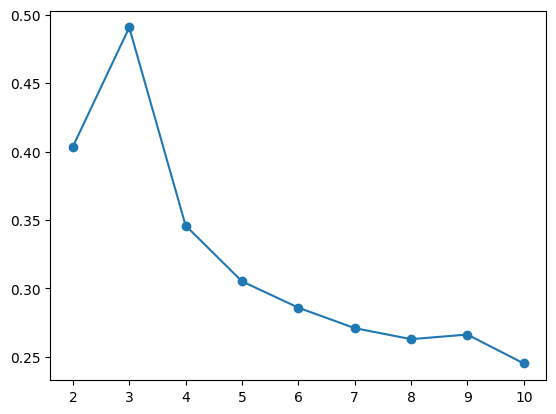

In [108]:
silhouette = []
for i in tqdm(range(2, 11)):
  agg = AgglomerativeClustering(n_clusters=i).fit(X_scaled)
  labels = agg.labels_
  score = silhouette_score(X_scaled, labels)
  silhouette.append(score)

plt.plot(range(2,11), silhouette, marker='o')
plt.show()

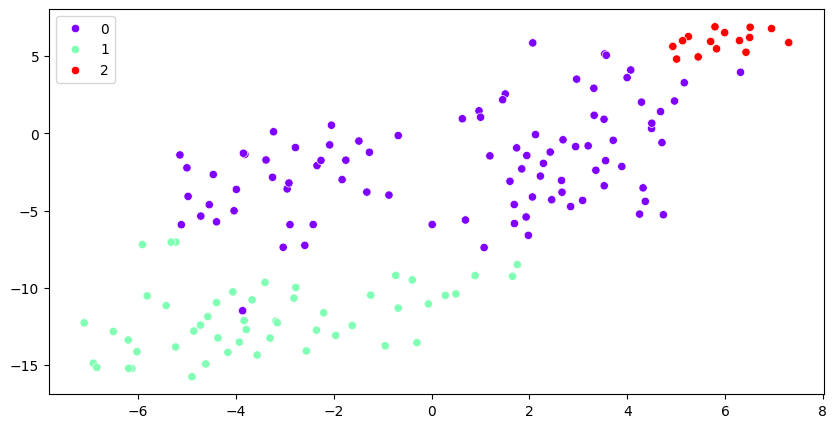

In [109]:
agg = AgglomerativeClustering(n_clusters=3).fit(X_scaled)
labels = agg.labels_
plt.figure(figsize=(10,5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='rainbow')
plt.show()

In [110]:
data['labels'] = labels

In [112]:
country[data['labels'] == 2]

,Country or region
0,Finland
1,Denmark
2,Norway
4,Netherlands
5,Switzerland
6,Sweden
7,New Zealand
8,Canada
9,Austria
10,Australia
